In [ ]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from torch.autograd import Variable
from tqdm import tqdm_notebook
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

import random
import torch.backends.cudnn as cudnn

#GPU 사용이 가능한지 체크해서, 가능하면 GPU를 사용하고, 가능하지 않으면 CPU를 사용하라는 명령어
print(torch.cuda.is_available())
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

#Ranom seed를 고정하여서 동일한 결과값이 나오게 하는 Definition
def set_seed(random_seed):
    # PyTorch의 random seed 고정
    torch.manual_seed(random_seed)

    # 완전히 똑같은 실험 환경을 재현하기 위함
    # 다른 모든 조건이 같을 때 학습 weight가 바뀌지 않게 함
    torch.cuda.manual_seed(random_seed)
    torch.cuda.manual_seed_all(random_seed) #  if use multi-GPU

    # Numpy seed 고정
    np.random.seed(random_seed)

    # CuDNN (딥러닝에 특화된 cuda 라이브러리) 제어
    cudnn.benchmark = False
    cudnn.deterministic = True # 단 이 옵션을 키면 연산 처리 속도가 느려짐

    # python random 라이브러리 randomness 제어
    # torchvision.transforms 사용하는 경우
    random.seed(random_seed)

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import scipy.stats
import warnings
from scipy.stats import norm
warnings.filterwarnings("ignore")
pd.options.display.float_format = '{:.3f}'.format

from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.forecasting.stl import STLForecast
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

def remove_high_pvalue_features(X, y, threshold=0.05, verbose=True):
    """
    OLS 회귀를 통해 p-value가 높은 변수들을 반복적으로 제거하는 함수

    Parameters:
        X : DataFrame - 독립변수
        y : Series or DataFrame - 종속변수
        threshold : float - p-value 기준값 (default 0.05)
        verbose : bool - 제거 로그 출력 여부

    Returns:
        model : 최종 statsmodels 회귀 모델
        X_ols : 최종 남은 변수 DataFrame
    """
    X_ols = sm.add_constant(X).copy().reset_index(drop=True)
    y = y.reset_index(drop=True)

    model = sm.OLS(y, X_ols).fit()

    while True:
        pvalues = model.pvalues.drop('const', errors='ignore')
        max_p = pvalues.max()
        if max_p > threshold:
            drop_feature = pvalues.idxmax()
            if verbose:
                print(f"❌ p-value {max_p:.4f}인 '{drop_feature}' 제거")
            X_ols = X_ols.drop(columns=drop_feature)
            y = y[:len(X_ols)].reset_index(drop=True)
            model = sm.OLS(y, X_ols).fit()
        else:
            break

    return model, X_ols

# 데이터 불러오기
original = pd.read_csv('c:\\python\\data2(filtered).csv', dtype={2: 'str'}).iloc[:,2:7]

original = original.reset_index(drop = True)
# 신고중량이 0으로 신고된 수입건 제외
original = original.drop(original[original['신고중량'] == 0].index)
# 1년간 수입한 일수가 100일 미만은 품목 제외
#year_ago = original['수리일자'].max() - 10000
#hs_hole = list(original[original['수리일자'] > year_ago]['HS10단위부호'].value_counts()[original[original['수리일자'] > year_ago]['HS10단위부호'].value_counts() < 100].index)
#original = original[~original['HS10단위부호'].isin(hs_hole)]

# 연도_주차 구하기
original['수리일자'] = original['수리일자'].astype(str)
original['수리일자'] = pd.to_datetime(original['수리일자'])
original['연도'] = original['수리일자'].dt.year
original['월'] = original['수리일자'].dt.month
original['주차'] = original['수리일자'].dt.isocalendar().week
original['연도주차'] = original['연도'] * 100 + original['주차']
original['연도주차'][(original['월'] == 1) & (original['주차'] > 5)] -= 100
original['연도주차'][(original['월'] == 12) & (original['주차'] < 5)] += 100
original['연도주차'] = original['연도주차'].apply(lambda x : str(x)[2:4] + '_' + str(x)[4:])

# 전체 연도_주차 데이터 생성
date_index = original['연도주차'].unique()
# 사용하는 컬럼 정리
use_col = ['HS10단위부호', '연도주차', '무역거래처국가코드', '신고중량', '과세가격미화금액']

# 외생변수 불러오기
exog_data = pd.read_csv('c:\\python\\Select_variables1.csv').reset_index(drop=True)
exog_columns = exog_data.columns.tolist()

p_eriod = -52

import arch

class LSTM(nn.Module):
    def __init__(self, num_classes, input_size, hidden_size, num_layers, seq_length):
        super(LSTM, self).__init__()
        self.num_classes = num_classes
        self.num_layers = num_layers
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.seq_length = seq_length

        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size,
                          num_layers=num_layers, batch_first=True)
        self.fc =  nn.Linear(hidden_size, num_classes)
        self.relu = nn.ReLU()

    def forward(self,x):
        h_0 = Variable(torch.zeros(self.num_layers, x.size(0), self.hidden_size))
        c_0 = Variable(torch.zeros(self.num_layers, x.size(0), self.hidden_size))
        out, _ = self.lstm(x, (h_0, c_0))
        out = self.fc(out[:, -1, :])
        out = self.relu(out)
        return out

In [ ]:

        
추출용 = [3102109000,3707901010,4407191000,8111000000,2701129010,2804701000,1511901000,305531000,302140000,1003901000,1003902000,1104230000,2710121000,3104200000,2905172000]
b = [59, 174, 85, 54, 48, 48, 44, 39, 38, 39, 39, 39, 39, 39, 30]
#추출용 = [3102109000]
#b = [58]

z = []
c = []
e = []
k = []
o = []
z_x = []
z_y = []

for i in range(0, len(추출용)):
  z.append(0) # 품목별 Highest CV를 반영하기 위해 List 생성
  c.append(0) # 품목별 CV값이 임계값 이상인 경우의 횟수를 반영하기 위한 List 생성
  k.append(0) # 임계값을 넘는 횟수
  o.append(0) # 위험경보 여부
  z_x.append(0) # Highest CV의 X값
  z_y.append(0) # Highest CV의 y값

for i in range(0, 8):
  e.append(0) # 품목별 8주간 CV값을 반영하기 위한 List 생성성

j = 0

for i in 추출용:
    print(f'HS Code : {i}')
    original[original['HS10단위부호'] == str(i)].sort_values(by = '수리일자', ascending = False)
    data = pd.DataFrame(columns = use_col)
    data = pd.concat([data, original[original['HS10단위부호'] == str(i)]])
    data = data.reset_index(drop=True)

    data = data.sort_values(by='수리일자', ascending=True).reset_index(drop=True)
    
    #
    ## 최근 52주간 수입단가(직전4주평균) 추이 파악
    #
    df_price = data[['연도주차', '과세가격미화금액', '신고중량']]
    df_price_week = df_price.groupby('연도주차')[['과세가격미화금액', '신고중량']].agg(['sum']).reset_index()
    df_price_week.columns = ['연도주차', '과세가격미화금액', '신고중량']


    # 수입이 없는 주차의 값을 0으로 생성
    df_price_week_hole = pd.DataFrame(columns = df_price_week.columns)
    for wk in set(date_index) - set(df_price_week['연도주차'].unique()):
        df_price_week_hole = pd.concat([df_price_week_hole, pd.DataFrame([{'연도주차': wk, '과세가격미화금액': 0, '신고중량': 0}])], ignore_index=True)
    df_price_week_total = pd.concat([df_price_week, df_price_week_hole]).sort_values('연도주차')

    # 해당 주차의 데이터를 직전 4주간 평균으로 대체
    price_w4 = []
    kg_w4 = []
    for x in range(0, len(df_price_week_total) - 3):
        price_w4.append(df_price_week_total[['과세가격미화금액']].iloc[x : x + 4].mean().iloc[0])
        kg_w4.append(df_price_week_total[['신고중량']].iloc[x : x + 4].mean().iloc[0])
    df_price_4w = df_price_week_total[3:]
    df_price_4w['과세가격미화금액'] = price_w4
    df_price_4w['신고중량'] = kg_w4
    df_price_4w = df_price_4w.reset_index(drop = True)
    df_price_4w['과세가격미화금액'] = df_price_4w['과세가격미화금액'].replace(0, np.nan).ffill()
    df_price_4w['신고중량'] = df_price_4w['신고중량'].replace(0, np.nan).ffill()
    df_price_4w['단가'] = df_price_4w['과세가격미화금액'] / df_price_4w['신고중량']
    df_price_4w = df_price_4w[['연도주차', '단가', '신고중량']]
    df_price_4w = df_price_4w.bfill()
    print(df_price_4w)
    
    residuals_list1 = []
    residuals_list2 = []

    for m in range(8, len(df_price_4w)):  # 최소 8개 이상 필요 (4주 평균+4주 윈도우)
        # 데이터 준비
        train_y = df_price_4w['단가'].iloc[m-8:m].values.reshape(-1, 1)
        test_y = df_price_4w['단가'].iloc[m:m+1].values.reshape(-1, 1)

        # 정규화
        ms = MinMaxScaler()
        y_train = ms.fit_transform(train_y)
        y_test = ms.transform(test_y)

        # 텐서 변환
        X_train = Variable(torch.Tensor(y_train)).reshape(-1, 8, 1)
        y_train_t = Variable(torch.Tensor(y_train))

        X_test = Variable(torch.Tensor(ms.transform(train_y[-8:]))).reshape(1, 8, 1)
        y_test_t = Variable(torch.Tensor(y_test))

        # 모델 정의
        model = LSTM(num_classes=1, input_size=1, hidden_size=16, num_layers=1, seq_length=8)
        criterion = torch.nn.MSELoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

        # 학습
        for epoch in range(30):
            output = model(X_train)
            loss = criterion(output, y_train_t)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        # 예측 및 역변환
        pred = model(X_test)
        pred_inv = ms.inverse_transform(pred.data.numpy())
        true_inv = ms.inverse_transform(y_test)

        # 잔차 저장
        residual = true_inv[0][0] - pred_inv[0][0]
        residuals_list1.append(residual)
    
    for n in range(8, len(df_price_4w)):  # 최소 8개 이상 필요 (4주 평균+4주 윈도우)
        # 데이터 준비
        train_y = df_price_4w['신고중량'].iloc[n-8:n].values.reshape(-1, 1)
        test_y = df_price_4w['신고중량'].iloc[n:n+1].values.reshape(-1, 1)

        # 정규화
        ms = MinMaxScaler()
        y_train = ms.fit_transform(train_y)
        y_test = ms.transform(test_y)

        # 텐서 변환
        X_train = Variable(torch.Tensor(y_train)).reshape(-1, 8, 1)
        y_train_t = Variable(torch.Tensor(y_train))

        X_test = Variable(torch.Tensor(ms.transform(train_y[-8:]))).reshape(1, 8, 1)
        y_test_t = Variable(torch.Tensor(y_test))

        # 모델 정의
        model = LSTM(num_classes=1, input_size=1, hidden_size=16, num_layers=1, seq_length=8)
        criterion = torch.nn.MSELoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

        # 학습
        for epoch in range(30):
            output = model(X_train)
            loss = criterion(output, y_train_t)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        # 예측 및 역변환
        pred = model(X_test)
        pred_inv = ms.inverse_transform(pred.data.numpy())
        true_inv = ms.inverse_transform(y_test)

        # 잔차 저장
        residual = true_inv[0][0] - pred_inv[0][0]
        residuals_list2.append(residual)

    for l in range(b[j]-8,b[j]):

        print(df_price_4w['연도주차'].iloc[-1-l] + '주차')
        #=================== 단가 percertile 구하기 ====================
        train_y = df_price_4w['단가'].iloc[p_eriod-l:-l].reset_index(drop=True)
        test_y = df_price_4w['단가'].iloc[p_eriod-l:-l+1].reset_index(drop=True)

        # 스케일링
        ms = MinMaxScaler()
        y_train = ms.fit_transform(train_y.values.reshape(-1, 1))
        y_test = ms.transform(test_y.values.reshape(-1, 1))

        # 텐서 변환 (단일 입력 특성)
        X_train_tensors_f = Variable(torch.Tensor(y_train).reshape(1, -1, 1))  # (1, seq_len=8, 1)
        X_test_tensors_f  = Variable(torch.Tensor(y_train[-8:].reshape(1, -1, 1)))  # 마지막 8개를 사용해 1-step 예측
        y_train_tensors = Variable(torch.Tensor(y_train))
        y_test_tensors = Variable(torch.Tensor(y_test))
        set_seed(3)

        # ========= 하이퍼 파라미터 구간(시작) ==========
        num_epochs = 100
        learning_rate = 0.0001

   
        # ========= 하이퍼 파라미터 구간(종료) ==========
        input_size = 1
        model = LSTM(num_classes=1, input_size=input_size, hidden_size=16, num_layers=1, seq_length=1)
        #model = biLSTM(num_classes, input_size, hidden_size, num_layers, X_train_tensors_f.shape[1])

        criterion = torch.nn.MSELoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

        for epoch in range(num_epochs):
            outputs = model.forward(X_train_tensors_f)
            optimizer.zero_grad()
            loss = criterion(outputs, y_train_tensors)
            loss.backward()

            optimizer.step()
            #if epoch % 100 == 0:
                #print("Epoch: %d, loss: %1.5f" % (epoch, loss.item()))

        test_predict = model(X_test_tensors_f)
        predicted = test_predict.data.numpy()
        #label_y = df_y_ms.data.numpy()

        predicted = ms.inverse_transform(predicted)
        print(predicted[0])

        # 1. biLSTM 예측
        test_predict1 = model(X_test_tensors_f)
        predicted1 = test_predict1.data.numpy()
        predicted2 = ms.inverse_transform(predicted1)
        print(predicted2)
        # 2. 실제값 (복원)
        true_y = ms.inverse_transform(y_test_tensors.data.numpy())

        # 3. 잔차 계산
        #residuals_1d = residuals.flatten()
        print('======================= 여기부터 GARCH 모델링 =================================')
        # 4. GARCH 모델에 적용
        residuals_list1 = np.array(residuals_list1)
        residuals_list1 = residuals_list1[np.isfinite(residuals_list1)]
        garch = arch.arch_model(residuals_list1, vol="GARCH", p=1, q=1)
        garch_fit = garch.fit(disp="off", options={"maxiter": 1000})
        garch_forecast = garch_fit.forecast(horizon=1)
        garch_std = np.sqrt(garch_forecast.variance.iloc[-1, 0])
        stand_quant = (test_y.iloc[0] - predicted[0])/ garch_std

        y=np.exp((scipy.stats.norm.cdf(stand_quant)*100 - 95)*np.log(5)/5)

      #=================== 신고중량 ======================

        train_y = df_price_4w['신고중량'].iloc[p_eriod-l:-l].reset_index(drop=True)
        test_y = df_price_4w['신고중량'].iloc[p_eriod-l:-l+1].reset_index(drop=True)

        # 스케일링
        ms = MinMaxScaler()
        y_train = ms.fit_transform(train_y.values.reshape(-1, 1))
        y_test = ms.transform(test_y.values.reshape(-1, 1))

        # 텐서 변환 (단일 입력 특성)
        X_train_tensors_f = Variable(torch.Tensor(y_train).reshape(1, -1, 1))  # (1, seq_len=8, 1)
        X_test_tensors_f  = Variable(torch.Tensor(y_train[-8:].reshape(1, -1, 1)))  # 마지막 8개를 사용해 1-step 예측
        y_train_tensors = Variable(torch.Tensor(y_train))
        y_test_tensors = Variable(torch.Tensor(y_test))
        set_seed(3)

        # ========= 하이퍼 파라미터 구간(시작) ==========
        num_epochs = 100
        learning_rate = 0.0001

   
        # ========= 하이퍼 파라미터 구간(종료) ==========
        input_size = 1
        model = LSTM(num_classes=1, input_size=input_size, hidden_size=16, num_layers=1, seq_length=1)
        #model = biLSTM(num_classes, input_size, hidden_size, num_layers, X_train_tensors_f.shape[1])

        criterion = torch.nn.MSELoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

        for epoch in range(num_epochs):
            outputs = model.forward(X_train_tensors_f)
            optimizer.zero_grad()
            loss = criterion(outputs, y_train_tensors)
            loss.backward()

            optimizer.step()
            #if epoch % 100 == 0:
                #print("Epoch: %d, loss: %1.5f" % (epoch, loss.item()))

        test_predict = model(X_test_tensors_f)
        predicted = test_predict.data.numpy()
        #label_y = df_y_ms.data.numpy()

        predicted = ms.inverse_transform(predicted)
        print(predicted[0])


        print('======================= 여기부터 GARCH 모델링 =================================')
        # 4. GARCH 모델에 적용
        residuals_list2 = np.array(residuals_list2)
        residuals_list2 = residuals_list2[np.isfinite(residuals_list2)]
        garch = arch.arch_model(residuals_list2, vol="GARCH", p=1, q=1)
        garch_fit = garch.fit(disp="off", options={"maxiter": 1000})
        garch_forecast = garch_fit.forecast(horizon=1)
        garch_std = np.sqrt(garch_forecast.variance.iloc[-1, 0])
        stand_quant = (test_y.iloc[0] - predicted[0])/ garch_std

        if(scipy.stats.norm.cdf(stand_quant)>0.5):
            x=np.exp((scipy.stats.norm.cdf(stand_quant)*100 - 95)*np.log(5)/5)
        else:
            x=np.exp(((1-scipy.stats.norm.cdf(stand_quant))*100 - 95)*np.log(5)/5)

        x = x.item() if isinstance(x, np.ndarray) else x
        y = y.item() if isinstance(y, np.ndarray) else y


        e[(l-b[j]+8)] = round(2/(1/y+1/x), 2)
        if(round(2/(1/y+1/x), 2)>1.85):
            k[j] += 1
        if(z[j] < round(2/(1/y+1/x), 2)):
            z[j] = round(2/(1/y+1/x), 2)
            c[j] = l

        if(z_x[j] < x):
            z_x[j] = x

        if(z_y[j] < y):
            z_y[j] = y

    if(z[j]>1.85):
        o[j] = 1

    import matplotlib.font_manager as fm

    plt.rc('font', family='Malgun Gothic')  # Windows (맑은 고딕)
    plt.rc('axes', unicode_minus=False)  # 마이너스(-) 기호 깨짐 방지

    x_labels = [df_price_4w['연도주차'].iloc[-1-l] for l in range(b[j]-8,b[j])]  # x축 라벨 생성
    plt.plot(x_labels, e)  # x축을 연도주차 값으로 설정
    plt.xticks(rotation=45)  # x축 라벨 회전 (가독성 개선)
    plt.xlabel("연도주차")  # x축 제목 추가
    plt.ylabel("위험 점수")  # y축 제목 추가
    plt.title("연도주차별 위험 점수 변화")  # 그래프 제목 추가
    plt.show()

    j += 1
print(z)
print(c)

# 구글드라이브에 있는 엑셀 파일을 불러와서 점수결과 저장하기
collect = pd.read_excel('c:\python\Compare_Models.xlsx', sheet_name="점수")
collect = pd.DataFrame(collect)
collect.loc[:14, 'Model20(1)'] = o
collect.loc[15, 'Model20(1)'] = np.sum(o)
collect.loc[:14, 'Model20(2)'] = z
collect.loc[15, 'Model20(2)'] = np.mean(z)
collect.to_excel('c:\python\Compare_Models.xlsx', sheet_name="점수", index=False)

collect1 = pd.read_excel('c:\python\Collectroc(t).xlsx', sheet_name="점수")
collect1 = pd.DataFrame(collect1)
collect1.loc[:14, 'y_scores[21]'] = z
collect1.to_excel('c:\python\Collectroc(t).xlsx', sheet_name="점수", index=False)

collect2 = pd.read_excel('c:\python\Collectroc(x).xlsx', sheet_name="점수")
collect2 = pd.DataFrame(collect2)
collect2.loc[:14, 'y_scores[21]'] = z_x
collect2.to_excel('c:\python\Collectroc(x).xlsx', sheet_name="점수", index=False)

collect3 = pd.read_excel('c:\python\Collectroc(y).xlsx', sheet_name="점수")
collect3 = pd.DataFrame(collect3)
collect3.loc[:14, 'y_scores[21]'] = z_y
collect3.to_excel('c:\python\Collectroc(y).xlsx', sheet_name="점수", index=False)

HS Code : 3926909000
      연도주차     단가        신고중량
0    17_04 12.645 1025925.581
1    17_05 12.325 1003770.569
2    17_06 12.990  896546.704
3    17_07 13.868  810003.951
4    17_08 13.864  786867.141
..     ...    ...         ...
292  22_34 12.959 1815633.348
293  22_35 12.448 1915482.234
294  22_36 12.514 1804240.198
295  22_37 13.038 1895153.324
296  22_38 12.894 1863081.698

[297 rows x 3 columns]
21_49주차
[11.1174345]
[[11.1174345]]
======================= 여기부터 GARCH 모델링 =================================
[1.2165002e+06]
======================= 여기부터 GARCH 모델링 =================================
21_48주차
[11.1174345]
[[11.1174345]]
======================= 여기부터 GARCH 모델링 =================================
[1.2165002e+06]
======================= 여기부터 GARCH 모델링 =================================
21_47주차
[11.1174345]
[[11.1174345]]
======================= 여기부터 GARCH 모델링 =================================
[1.2165002e+06]
======================= 여기부터 GARCH 모델링 =================================
2

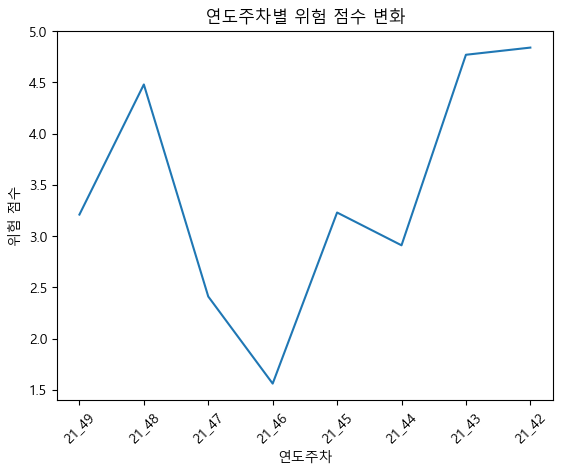

HS Code : 7326909000
      연도주차    단가        신고중량
0    17_04 3.239 9168390.099
1    17_05 3.083 8986749.600
2    17_06 3.218 8269841.990
3    17_07 3.697 7854248.619
4    17_08 3.828 7793786.026
..     ...   ...         ...
292  22_34 4.186 8816636.180
293  22_35 4.134 8974905.138
294  22_36 4.075 8042241.078
295  22_37 4.002 8195776.474
296  22_38 4.381 7865576.680

[297 rows x 3 columns]
21_49주차
[3.8340104]
[[3.8340104]]
======================= 여기부터 GARCH 모델링 =================================
[7.3458285e+06]
======================= 여기부터 GARCH 모델링 =================================
21_48주차
[3.7144606]
[[3.7144606]]
======================= 여기부터 GARCH 모델링 =================================
[7.3458285e+06]
======================= 여기부터 GARCH 모델링 =================================
21_47주차
[3.6239128]
[[3.6239128]]
======================= 여기부터 GARCH 모델링 =================================
[7.3458285e+06]
======================= 여기부터 GARCH 모델링 =================================
21_46주차
[3.6239128]

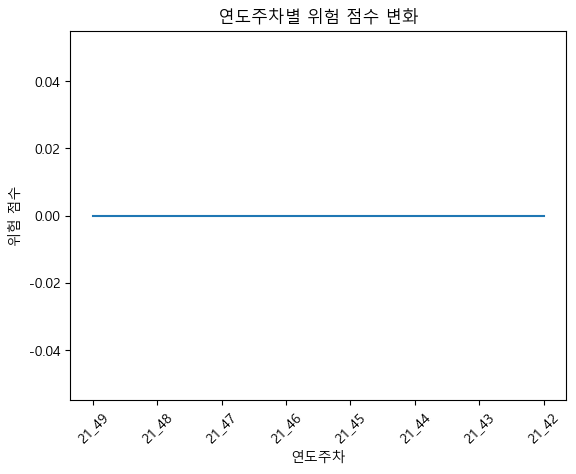

HS Code : 8708999000
      연도주차     단가        신고중량
0    17_04 14.075 1247682.893
1    17_05 13.650 1234876.845
2    17_06 13.754 1169274.438
3    17_07 14.186 1085290.376
4    17_08 14.299 1187871.823
..     ...    ...         ...
292  22_34 14.548 1197477.282
293  22_35 14.015 1312549.034
294  22_36 14.086 1032812.910
295  22_37 13.684 1069049.869
296  22_38 13.629 1100040.657

[297 rows x 3 columns]
21_49주차
[13.163044]
[[13.163044]]
======================= 여기부터 GARCH 모델링 =================================
[894438.9]
======================= 여기부터 GARCH 모델링 =================================
21_48주차
[13.437123]
[[13.437123]]
======================= 여기부터 GARCH 모델링 =================================
[894438.9]
======================= 여기부터 GARCH 모델링 =================================
21_47주차
[13.437123]
[[13.437123]]
======================= 여기부터 GARCH 모델링 =================================
[894438.9]
======================= 여기부터 GARCH 모델링 =================================
21_46주차
[13.6138935]
[

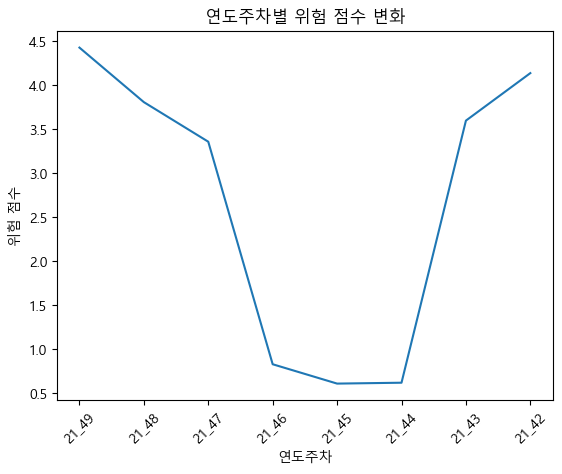

HS Code : 2106909099
      연도주차     단가        신고중량
0    17_04 16.567 1096069.847
1    17_05 17.445 1090277.061
2    17_06 18.573 1065622.447
3    17_07 17.266 1079067.502
4    17_08 18.938 1068644.909
..     ...    ...         ...
292  22_34 22.993 1792636.330
293  22_35 23.689 1812879.627
294  22_36 22.930 1733061.597
295  22_37 24.824 1557516.093
296  22_38 22.206 1725581.801

[297 rows x 3 columns]
21_49주차
[21.742243]
[[21.742243]]
======================= 여기부터 GARCH 모델링 =================================
[1.3506785e+06]
======================= 여기부터 GARCH 모델링 =================================
21_48주차
[21.742243]
[[21.742243]]
======================= 여기부터 GARCH 모델링 =================================
[1.3506785e+06]
======================= 여기부터 GARCH 모델링 =================================
21_47주차
[21.742243]
[[21.742243]]
======================= 여기부터 GARCH 모델링 =================================
[1.3506785e+06]
======================= 여기부터 GARCH 모델링 =================================
21_46주차

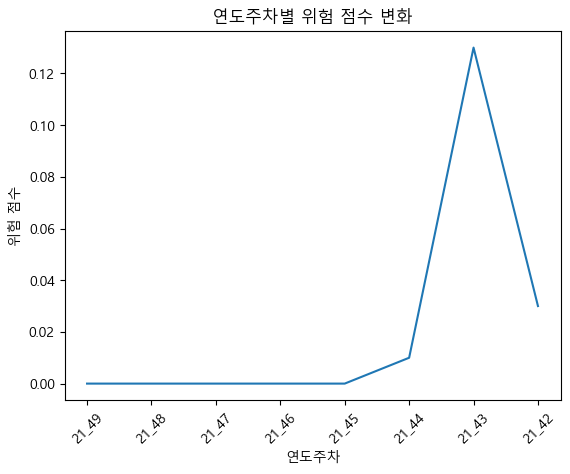

HS Code : 4911990000
      연도주차     단가      신고중량
0    17_04 32.321 19529.869
1    17_05 30.090 19750.013
2    17_06 35.127 18579.112
3    17_07 50.896 16942.203
4    17_08 37.478 22503.740
..     ...    ...       ...
292  22_34 59.026 36373.505
293  22_35 53.129 31194.135
294  22_36 53.195 26486.489
295  22_37 46.858 28118.647
296  22_38 28.951 31057.943

[297 rows x 3 columns]
21_49주차
[15.975684]
[[15.975684]]
======================= 여기부터 GARCH 모델링 =================================
[29278.22]
======================= 여기부터 GARCH 모델링 =================================
21_48주차
[15.975684]
[[15.975684]]
======================= 여기부터 GARCH 모델링 =================================
[24080.367]
======================= 여기부터 GARCH 모델링 =================================
21_47주차
[15.975684]
[[15.975684]]
======================= 여기부터 GARCH 모델링 =================================
[24080.367]
======================= 여기부터 GARCH 모델링 =================================
21_46주차
[15.975684]
[[15.975684]]
==========

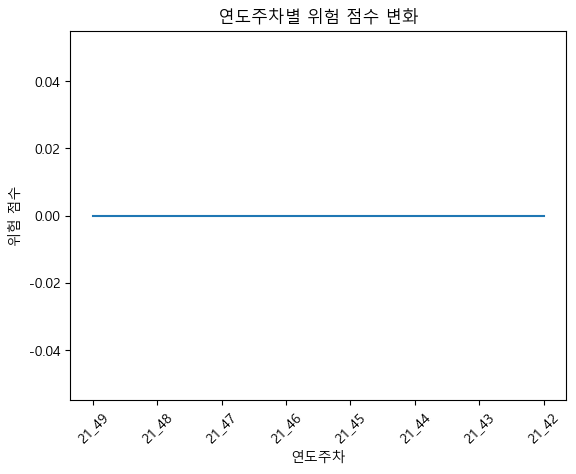

HS Code : 6403999000
      연도주차     단가       신고중량
0    17_04 42.573 307600.675
1    17_05 42.202 332294.615
2    17_06 45.631 292290.022
3    17_07 45.425 288711.050
4    17_08 46.147 267225.037
..     ...    ...        ...
292  22_34 49.753 314483.035
293  22_35 48.361 319968.488
294  22_36 46.162 307661.767
295  22_37 44.059 322508.380
296  22_38 45.232 312421.980

[297 rows x 3 columns]
21_49주차
[48.10385]
[[48.10385]]
======================= 여기부터 GARCH 모델링 =================================
[149261.5]
======================= 여기부터 GARCH 모델링 =================================
21_48주차
[48.10385]
[[48.10385]]
======================= 여기부터 GARCH 모델링 =================================
[149261.5]
======================= 여기부터 GARCH 모델링 =================================
21_47주차
[48.10385]
[[48.10385]]
======================= 여기부터 GARCH 모델링 =================================
[149261.5]
======================= 여기부터 GARCH 모델링 =================================
21_46주차
[48.10385]
[[48.10385]]
========

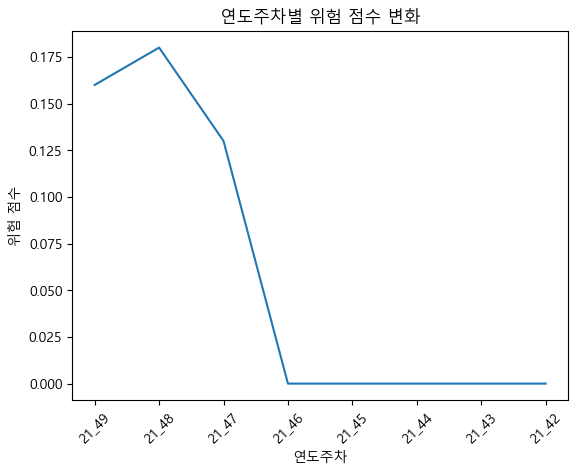

HS Code : 9031809099
      연도주차      단가       신고중량
0    17_04 129.171 157944.184
1    17_05 108.770 155291.110
2    17_06 108.294 172098.109
3    17_07 128.855 142177.506
4    17_08 137.668 150982.218
..     ...     ...        ...
292  22_34 107.316 196206.079
293  22_35 115.643 201236.136
294  22_36 132.293 185872.607
295  22_37 136.131 174217.334
296  22_38 152.741 143387.679

[297 rows x 3 columns]
21_49주차
[90.91184]
[[90.91184]]
======================= 여기부터 GARCH 모델링 =================================
[107369.65]
======================= 여기부터 GARCH 모델링 =================================
21_48주차
[90.91184]
[[90.91184]]
======================= 여기부터 GARCH 모델링 =================================
[107369.65]
======================= 여기부터 GARCH 모델링 =================================
21_47주차
[90.91184]
[[90.91184]]
======================= 여기부터 GARCH 모델링 =================================
[107369.65]
======================= 여기부터 GARCH 모델링 =================================
21_46주차
[90.91184]
[[90.9

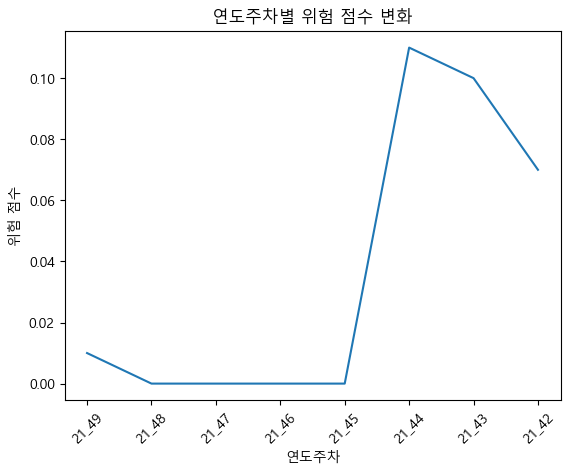

HS Code : 8542391000
      연도주차       단가      신고중량
0    17_04 1776.562 62373.847
1    17_05 1710.646 56980.096
2    17_06 1700.125 57142.753
3    17_07 1745.668 57212.506
4    17_08 1808.697 60409.421
..     ...      ...       ...
292  22_34 3218.867 57436.982
293  22_35 3041.957 57382.773
294  22_36 3111.084 55815.490
295  22_37 3258.838 54519.836
296  22_38 3379.894 54799.348

[297 rows x 3 columns]
21_49주차
[2242.6191]
[[2242.6191]]
======================= 여기부터 GARCH 모델링 =================================
[53577.812]
======================= 여기부터 GARCH 모델링 =================================
21_48주차
[2132.867]
[[2132.867]]
======================= 여기부터 GARCH 모델링 =================================
[53577.812]
======================= 여기부터 GARCH 모델링 =================================
21_47주차
[2121.8987]
[[2121.8987]]
======================= 여기부터 GARCH 모델링 =================================
[53577.812]
======================= 여기부터 GARCH 모델링 =================================
21_46주차
[2108.9568]
[

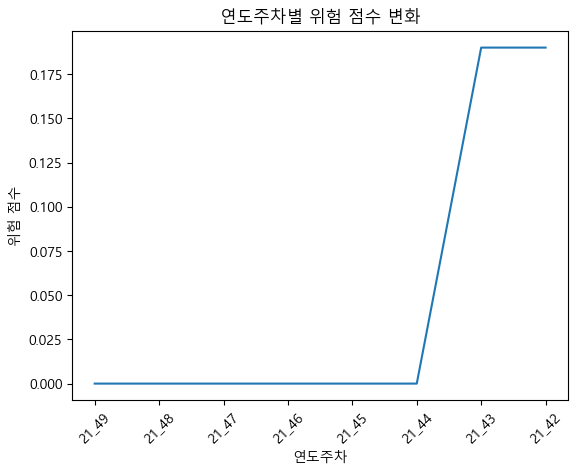

HS Code : 6109101000
      연도주차     단가       신고중량
0    17_04 20.080 407322.358
1    17_05 21.565 369330.457
2    17_06 22.951 328115.994
3    17_07 22.459 320495.424
4    17_08 21.970 368718.817
..     ...    ...        ...
292  22_34 24.510 331834.580
293  22_35 22.816 352385.923
294  22_36 22.607 312789.645
295  22_37 21.972 286627.134
296  22_38 21.345 268384.628

[297 rows x 3 columns]
21_49주차
[19.041483]
[[19.041483]]
======================= 여기부터 GARCH 모델링 =================================
[220407.89]
======================= 여기부터 GARCH 모델링 =================================
21_48주차
[19.041483]
[[19.041483]]
======================= 여기부터 GARCH 모델링 =================================
[201389.16]
======================= 여기부터 GARCH 모델링 =================================
21_47주차
[19.041483]
[[19.041483]]
======================= 여기부터 GARCH 모델링 =================================
[196411.53]
======================= 여기부터 GARCH 모델링 =================================
21_46주차
[19.041483]
[[19.041483

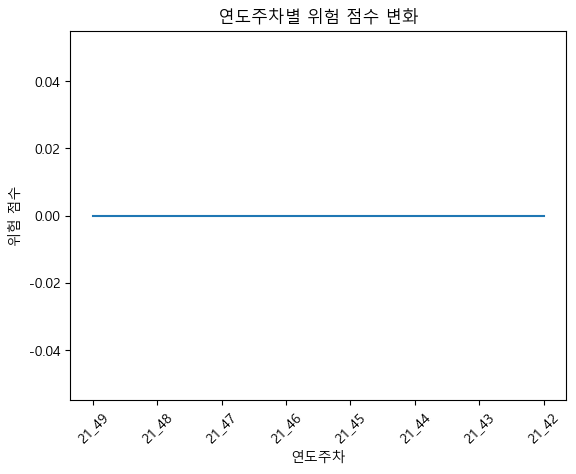

HS Code : 2934996000
      연도주차     단가      신고중량
0    17_04  8.498 49632.923
1    17_05  8.632 57464.182
2    17_06  8.808 60682.206
3    17_07  8.798 59678.369
4    17_08  9.343 50440.159
..     ...    ...       ...
292  22_34 45.139 18624.338
293  22_35 69.964 11267.689
294  22_36 45.700 15034.463
295  22_37 19.447 15005.874
296  22_38 25.918  6977.896

[297 rows x 3 columns]
21_49주차
[8.716823]
[[8.716823]]
======================= 여기부터 GARCH 모델링 =================================
[1846.8707]
======================= 여기부터 GARCH 모델링 =================================
21_48주차
[8.716823]
[[8.716823]]
======================= 여기부터 GARCH 모델링 =================================
[1846.8707]
======================= 여기부터 GARCH 모델링 =================================
21_47주차
[8.716823]
[[8.716823]]
======================= 여기부터 GARCH 모델링 =================================
[1846.8707]
======================= 여기부터 GARCH 모델링 =================================
21_46주차
[8.716823]
[[8.716823]]
=================

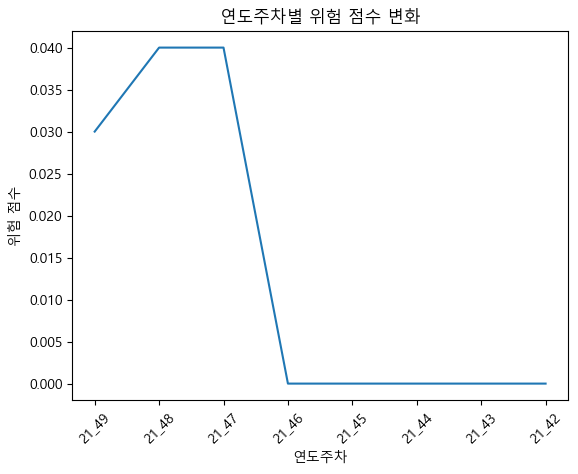

HS Code : 4016930000
      연도주차     단가       신고중량
0    17_04 33.773  88152.130
1    17_05 37.114  84985.181
2    17_06 39.994  84495.300
3    17_07 43.464  79589.242
4    17_08 41.431  90679.888
..     ...    ...        ...
292  22_34 35.527 100362.256
293  22_35 34.124 116410.851
294  22_36 36.241  93017.522
295  22_37 39.299  82961.592
296  22_38 41.360  81901.151

[297 rows x 3 columns]
21_49주차
[31.43675]
[[31.43675]]
======================= 여기부터 GARCH 모델링 =================================
[68148.04]
======================= 여기부터 GARCH 모델링 =================================
21_48주차
[31.43675]
[[31.43675]]
======================= 여기부터 GARCH 모델링 =================================
[68148.04]
======================= 여기부터 GARCH 모델링 =================================
21_47주차
[34.08002]
[[34.08002]]
======================= 여기부터 GARCH 모델링 =================================
[68148.04]
======================= 여기부터 GARCH 모델링 =================================
21_46주차
[34.08002]
[[34.08002]]
========

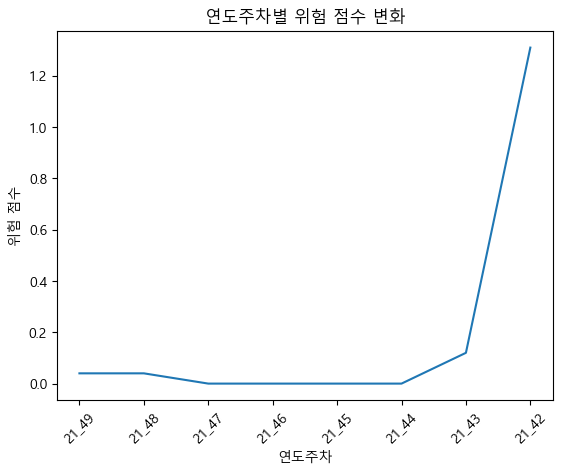

HS Code : 6110200000
      연도주차     단가       신고중량
0    17_04 22.240 361785.894
1    17_05 24.727 298878.713
2    17_06 27.402 225267.700
3    17_07 29.106 175229.062
4    17_08 31.183 146024.755
..     ...    ...        ...
292  22_34 27.774 616067.789
293  22_35 27.079 664306.128
294  22_36 27.678 633297.234
295  22_37 26.838 616346.393
296  22_38 27.102 584630.699

[297 rows x 3 columns]
21_49주차
[23.942795]
[[23.942795]]
======================= 여기부터 GARCH 모델링 =================================
[71602.15]
======================= 여기부터 GARCH 모델링 =================================
21_48주차
[23.942795]
[[23.942795]]
======================= 여기부터 GARCH 모델링 =================================
[71602.15]
======================= 여기부터 GARCH 모델링 =================================
21_47주차
[23.942795]
[[23.942795]]
======================= 여기부터 GARCH 모델링 =================================
[71602.15]
======================= 여기부터 GARCH 모델링 =================================
21_46주차
[23.942795]
[[23.942795]]


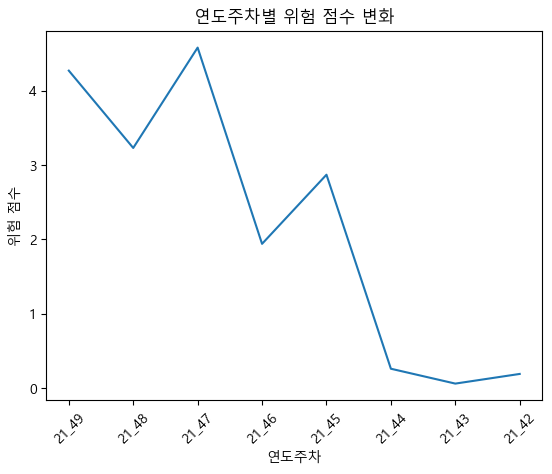

HS Code : 6211499000
      연도주차      단가      신고중량
0    17_04  36.351 26163.515
1    17_05  35.936 24753.456
2    17_06  29.483 23216.503
3    17_07  32.605 19810.625
4    17_08  41.699 19663.601
..     ...     ...       ...
292  22_34 124.614 33354.493
293  22_35 126.914 32804.025
294  22_36 134.758 30045.096
295  22_37 130.125 33029.579
296  22_38 136.045 31698.336

[297 rows x 3 columns]
21_49주차
[55.326756]
[[55.326756]]
======================= 여기부터 GARCH 모델링 =================================
[18280.738]
======================= 여기부터 GARCH 모델링 =================================
21_48주차
[55.326756]
[[55.326756]]
======================= 여기부터 GARCH 모델링 =================================
[18280.738]
======================= 여기부터 GARCH 모델링 =================================
21_47주차
[55.326756]
[[55.326756]]
======================= 여기부터 GARCH 모델링 =================================
[18280.738]
======================= 여기부터 GARCH 모델링 =================================
21_46주차
[55.32676]
[[55.32676]]

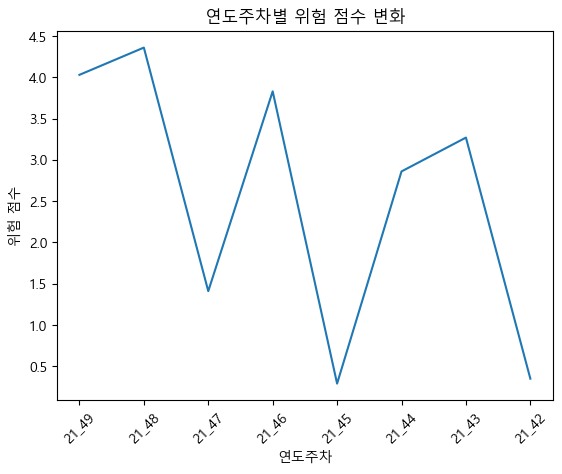

HS Code : 4202999000
      연도주차     단가       신고중량
0    17_04 11.930 114854.454
1    17_05 13.510  97367.585
2    17_06 15.117  84721.380
3    17_07 17.806  64762.410
4    17_08 24.105  50929.776
..     ...    ...        ...
292  22_34 37.997  63336.199
293  22_35 37.557  67878.172
294  22_36 38.778  65572.161
295  22_37 37.615  71488.576
296  22_38 39.546  67800.206

[297 rows x 3 columns]
21_49주차
[30.403524]
[[30.403524]]
======================= 여기부터 GARCH 모델링 =================================
[31464.]
======================= 여기부터 GARCH 모델링 =================================
21_48주차
[30.403524]
[[30.403524]]
======================= 여기부터 GARCH 모델링 =================================
[31464.]
======================= 여기부터 GARCH 모델링 =================================
21_47주차
[30.403524]
[[30.403524]]
======================= 여기부터 GARCH 모델링 =================================
[31464.]
======================= 여기부터 GARCH 모델링 =================================
21_46주차
[30.403524]
[[30.403524]]
======

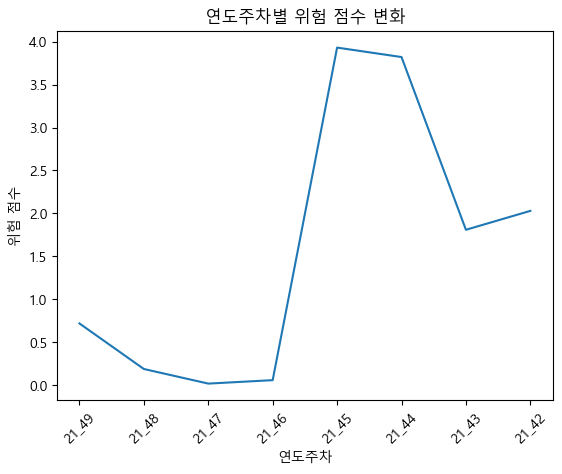

HS Code : 3304991000
      연도주차     단가       신고중량
0    17_04 60.484 438875.551
1    17_05 62.220 442029.125
2    17_06 64.621 454161.740
3    17_07 65.076 437650.124
4    17_08 53.091 483890.537
..     ...    ...        ...
292  22_34 86.153 803500.959
293  22_35 83.161 746905.818
294  22_36 86.268 602836.532
295  22_37 83.825 640390.917
296  22_38 88.960 667616.950

[297 rows x 3 columns]
21_49주차
[75.57235]
[[75.57235]]
======================= 여기부터 GARCH 모델링 =================================
[594627.94]
======================= 여기부터 GARCH 모델링 =================================
21_48주차
[75.57235]
[[75.57235]]
======================= 여기부터 GARCH 모델링 =================================
[594627.94]
======================= 여기부터 GARCH 모델링 =================================
21_47주차
[75.57235]
[[75.57235]]
======================= 여기부터 GARCH 모델링 =================================
[594627.94]
======================= 여기부터 GARCH 모델링 =================================
21_46주차
[75.57235]
[[75.57235]]
=====

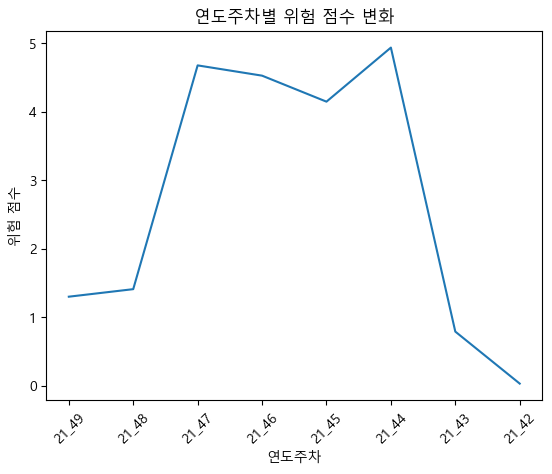

HS Code : 8544429090
      연도주차     단가       신고중량
0    17_04 22.442 133268.811
1    17_05 19.936 150909.589
2    17_06 20.806 142360.843
3    17_07 20.254 134948.973
4    17_08 21.626 132293.881
..     ...    ...        ...
292  22_34 31.205 121301.305
293  22_35 33.180 113849.449
294  22_36 38.848  95069.248
295  22_37 38.887  89062.672
296  22_38 38.639  83172.104

[297 rows x 3 columns]
21_49주차
[26.857374]
[[26.857374]]
======================= 여기부터 GARCH 모델링 =================================
[70308.64]
======================= 여기부터 GARCH 모델링 =================================
21_48주차
[26.857374]
[[26.857374]]
======================= 여기부터 GARCH 모델링 =================================
[70308.64]
======================= 여기부터 GARCH 모델링 =================================
21_47주차
[26.857374]
[[26.857374]]
======================= 여기부터 GARCH 모델링 =================================
[70308.64]
======================= 여기부터 GARCH 모델링 =================================
21_46주차
[26.857374]
[[26.857374]]


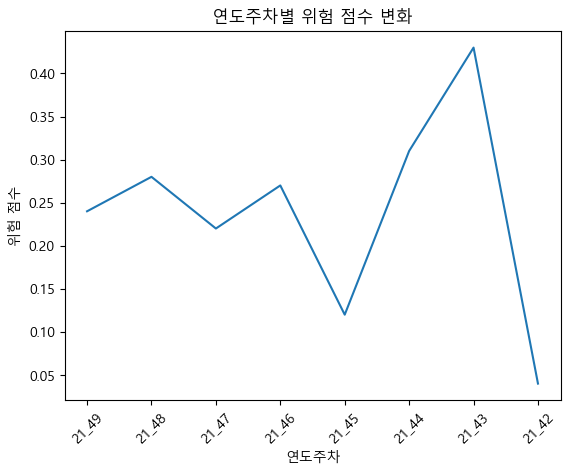

HS Code : 8481801090
      연도주차     단가       신고중량
0    17_04 24.419 867375.544
1    17_05 24.743 877752.450
2    17_06 27.989 756466.539
3    17_07 30.936 683371.785
4    17_08 35.243 624223.503
..     ...    ...        ...
292  22_34 35.294 664890.252
293  22_35 36.869 714942.677
294  22_36 40.011 597877.847
295  22_37 38.783 631414.445
296  22_38 37.918 612214.183

[297 rows x 3 columns]
21_49주차
[22.513607]
[[22.513607]]
======================= 여기부터 GARCH 모델링 =================================
[616090.1]
======================= 여기부터 GARCH 모델링 =================================
21_48주차
[22.513607]
[[22.513607]]
======================= 여기부터 GARCH 모델링 =================================
[616090.1]
======================= 여기부터 GARCH 모델링 =================================
21_47주차
[22.513607]
[[22.513607]]
======================= 여기부터 GARCH 모델링 =================================
[616090.1]
======================= 여기부터 GARCH 모델링 =================================
21_46주차
[22.513607]
[[22.513607]]


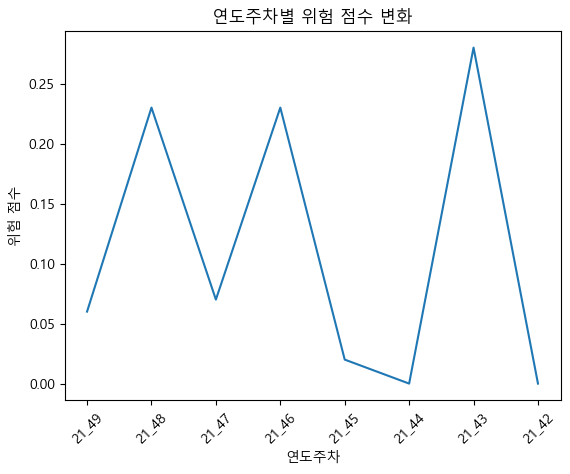

HS Code : 3304999000
      연도주차     단가      신고중량
0    17_04 59.281 75607.321
1    17_05 63.561 76195.666
2    17_06 62.604 90904.970
3    17_07 68.242 84830.791
4    17_08 61.418 80356.355
..     ...    ...       ...
292  22_34 76.922 63785.081
293  22_35 87.618 63696.939
294  22_36 87.240 57699.559
295  22_37 91.778 52287.780
296  22_38 96.245 62910.697

[297 rows x 3 columns]
21_49주차
[71.88583]
[[71.88583]]
======================= 여기부터 GARCH 모델링 =================================
[51998.953]
======================= 여기부터 GARCH 모델링 =================================
21_48주차
[71.88583]
[[71.88583]]
======================= 여기부터 GARCH 모델링 =================================
[51998.953]
======================= 여기부터 GARCH 모델링 =================================
21_47주차
[70.63237]
[[70.63237]]
======================= 여기부터 GARCH 모델링 =================================
[51998.953]
======================= 여기부터 GARCH 모델링 =================================
21_46주차
[67.371124]
[[67.371124]]
===============

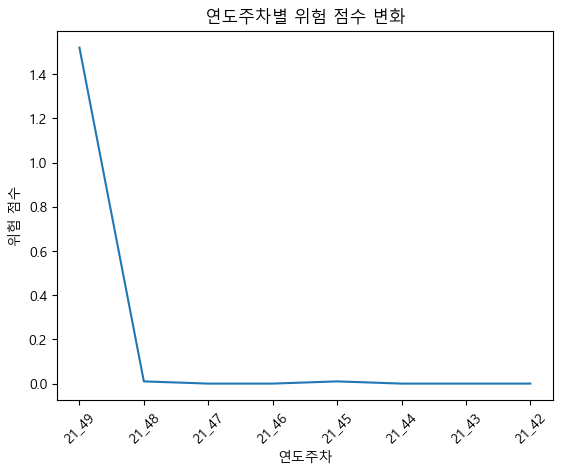

HS Code : 8543709090
      연도주차      단가       신고중량
0    17_04 227.436  58874.088
1    17_05 224.701  57636.610
2    17_06 221.690  58398.750
3    17_07 223.516  58332.744
4    17_08 225.643  62635.122
..     ...     ...        ...
292  22_34 219.972 115375.374
293  22_35 220.214 112118.800
294  22_36 239.236  99513.783
295  22_37 221.137 106693.282
296  22_38 231.450 106909.689

[297 rows x 3 columns]
21_49주차
[106.178024]
[[106.178024]]
======================= 여기부터 GARCH 모델링 =================================
[93291.516]
======================= 여기부터 GARCH 모델링 =================================
21_48주차
[106.178024]
[[106.178024]]
======================= 여기부터 GARCH 모델링 =================================
[93291.516]
======================= 여기부터 GARCH 모델링 =================================
21_47주차
[106.178024]
[[106.178024]]
======================= 여기부터 GARCH 모델링 =================================
[93291.516]
======================= 여기부터 GARCH 모델링 =================================
21_46주차
[106.

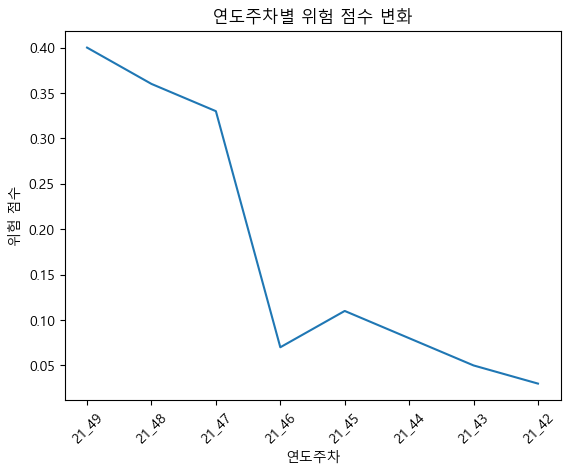

HS Code : 6404199000
      연도주차     단가       신고중량
0    17_04 24.079 433706.005
1    17_05 24.276 489646.895
2    17_06 26.045 464463.766
3    17_07 26.715 411383.820
4    17_08 28.661 373057.142
..     ...    ...        ...
292  22_34 26.210 464050.823
293  22_35 26.889 495340.597
294  22_36 26.242 544325.299
295  22_37 25.719 552088.040
296  22_38 26.210 549057.174

[297 rows x 3 columns]
21_49주차
[21.762138]
[[21.762138]]
======================= 여기부터 GARCH 모델링 =================================
[383169.66]
======================= 여기부터 GARCH 모델링 =================================
21_48주차
[21.762138]
[[21.762138]]
======================= 여기부터 GARCH 모델링 =================================
[383169.66]
======================= 여기부터 GARCH 모델링 =================================
21_47주차
[21.762138]
[[21.762138]]
======================= 여기부터 GARCH 모델링 =================================
[383169.66]
======================= 여기부터 GARCH 모델링 =================================
21_46주차
[21.762138]
[[21.762138

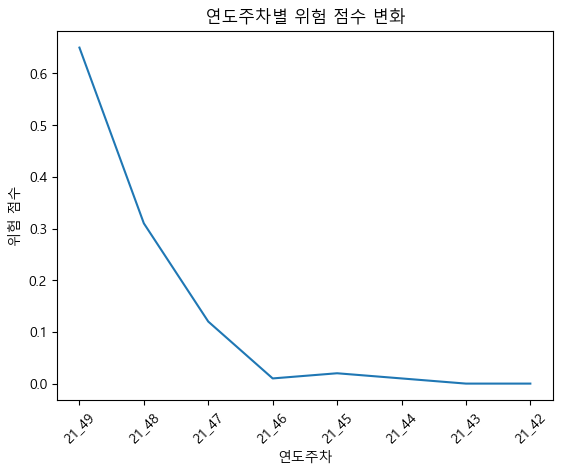

HS Code : 3004909900
      연도주차     단가        신고중량
0    17_04 50.256  813208.066
1    17_05 51.854  857624.964
2    17_06 48.439  877252.749
3    17_07 42.512  922404.462
4    17_08 39.613 1052187.394
..     ...    ...         ...
292  22_34 46.072 1100536.037
293  22_35 50.953 1040200.013
294  22_36 64.322  954193.409
295  22_37 57.557 1010066.636
296  22_38 54.954 1152317.664

[297 rows x 3 columns]
21_49주차
[42.159515]
[[42.159515]]
======================= 여기부터 GARCH 모델링 =================================
[884812.]
======================= 여기부터 GARCH 모델링 =================================
21_48주차
[42.159515]
[[42.159515]]
======================= 여기부터 GARCH 모델링 =================================
[884812.]
======================= 여기부터 GARCH 모델링 =================================
21_47주차
[42.159515]
[[42.159515]]
======================= 여기부터 GARCH 모델링 =================================
[884812.]
======================= 여기부터 GARCH 모델링 =================================
21_46주차
[42.159515]
[[42.

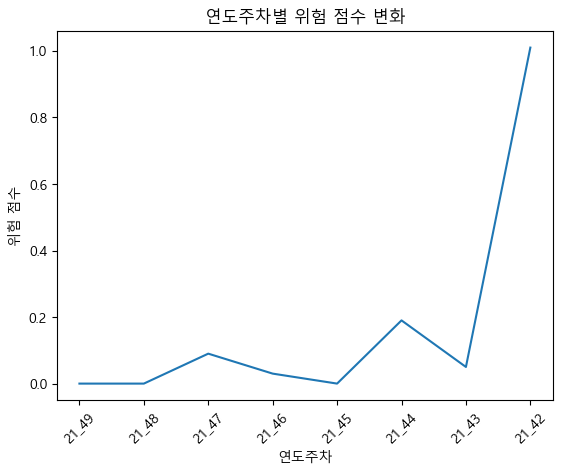

HS Code : 8542311000
      연도주차       단가      신고중량
0    17_04 4617.302 62174.914
1    17_05 4600.665 59881.381
2    17_06 4609.463 60889.965
3    17_07 4683.508 60436.896
4    17_08 4537.578 64141.726
..     ...      ...       ...
292  22_34 7870.564 75278.936
293  22_35 7828.619 75478.242
294  22_36 7860.660 70760.202
295  22_37 8124.353 74194.129
296  22_38 8210.185 72670.298

[297 rows x 3 columns]
21_49주차
[5708.8857]
[[5708.8857]]
======================= 여기부터 GARCH 모델링 =================================
[57198.12]
======================= 여기부터 GARCH 모델링 =================================
21_48주차
[5708.8857]
[[5708.8857]]
======================= 여기부터 GARCH 모델링 =================================
[57198.12]
======================= 여기부터 GARCH 모델링 =================================
21_47주차
[5708.8857]
[[5708.8857]]
======================= 여기부터 GARCH 모델링 =================================
[57198.12]
======================= 여기부터 GARCH 모델링 =================================
21_46주차
[5708.8857]
[[

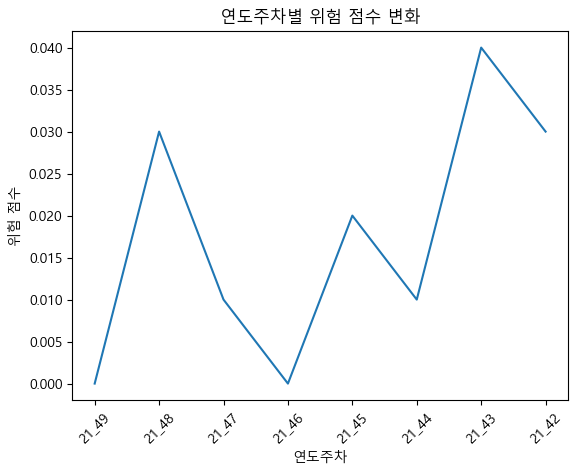

HS Code : 4901999000
      연도주차     단가       신고중량
0    17_04 17.640 100175.458
1    17_05 16.106 131106.952
2    17_06 17.220 130545.646
3    17_07 17.322 141892.769
4    17_08 16.836 172702.815
..     ...    ...        ...
292  22_34 19.195 108195.469
293  22_35 18.625 118643.860
294  22_36 18.841  99451.189
295  22_37 20.885  86145.057
296  22_38 20.862  80884.167

[297 rows x 3 columns]
21_49주차
[16.761543]
[[16.761543]]
======================= 여기부터 GARCH 모델링 =================================
[83803.1]
======================= 여기부터 GARCH 모델링 =================================
21_48주차
[16.761543]
[[16.761543]]
======================= 여기부터 GARCH 모델링 =================================
[83803.1]
======================= 여기부터 GARCH 모델링 =================================
21_47주차
[16.761543]
[[16.761543]]
======================= 여기부터 GARCH 모델링 =================================
[83803.1]
======================= 여기부터 GARCH 모델링 =================================
21_46주차
[16.761543]
[[16.761543]]
===

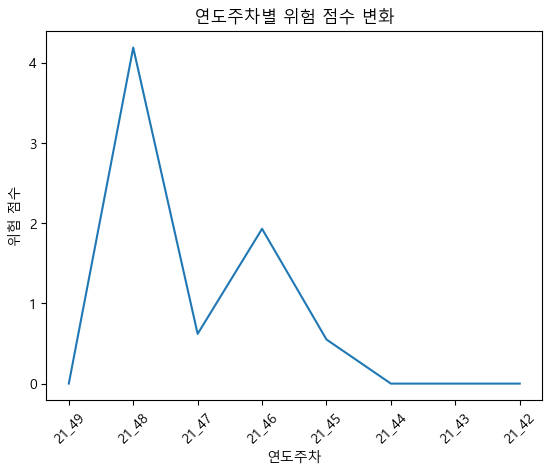

HS Code : 8473309090
      연도주차      단가      신고중량
0    17_04 103.438 98141.215
1    17_05  89.920 95195.908
2    17_06  93.011 93596.876
3    17_07  91.536 89812.626
4    17_08  83.603 98618.909
..     ...     ...       ...
292  22_34 127.420 64333.353
293  22_35 126.451 67401.267
294  22_36 120.080 64354.283
295  22_37 133.878 60193.390
296  22_38 125.217 63691.076

[297 rows x 3 columns]
21_49주차
[101.95264]
[[101.95264]]
======================= 여기부터 GARCH 모델링 =================================
[76660.06]
======================= 여기부터 GARCH 모델링 =================================
21_48주차
[101.95264]
[[101.95264]]
======================= 여기부터 GARCH 모델링 =================================
[76660.06]
======================= 여기부터 GARCH 모델링 =================================
21_47주차
[101.95264]
[[101.95264]]
======================= 여기부터 GARCH 모델링 =================================
[76660.06]
======================= 여기부터 GARCH 모델링 =================================
21_46주차
[101.95263]
[[101.95263]]


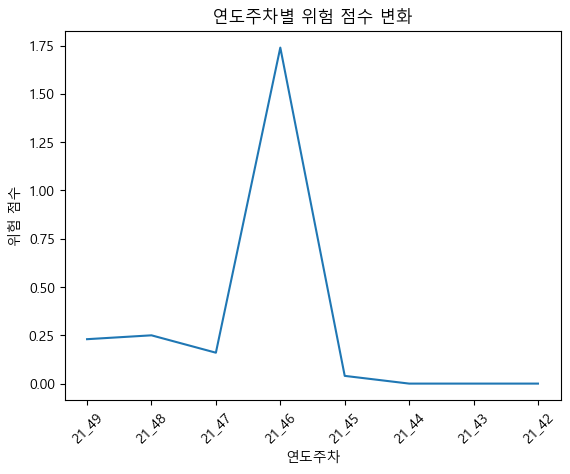

HS Code : 6307909000
      연도주차    단가       신고중량
0    17_04 5.604 594914.831
1    17_05 5.820 550737.782
2    17_06 5.679 491903.032
3    17_07 6.246 378045.128
4    17_08 6.606 346522.624
..     ...   ...        ...
292  22_34 8.968 594296.857
293  22_35 8.516 634583.744
294  22_36 8.467 620683.383
295  22_37 8.579 658795.785
296  22_38 8.369 682976.044

[297 rows x 3 columns]
21_49주차
[7.835827]
[[7.835827]]
======================= 여기부터 GARCH 모델링 =================================
[412525.56]
======================= 여기부터 GARCH 모델링 =================================
21_48주차
[7.835827]
[[7.835827]]
======================= 여기부터 GARCH 모델링 =================================
[412525.56]
======================= 여기부터 GARCH 모델링 =================================
21_47주차
[7.835827]
[[7.835827]]
======================= 여기부터 GARCH 모델링 =================================
[412525.56]
======================= 여기부터 GARCH 모델링 =================================
21_46주차
[7.835827]
[[7.835827]]
=================

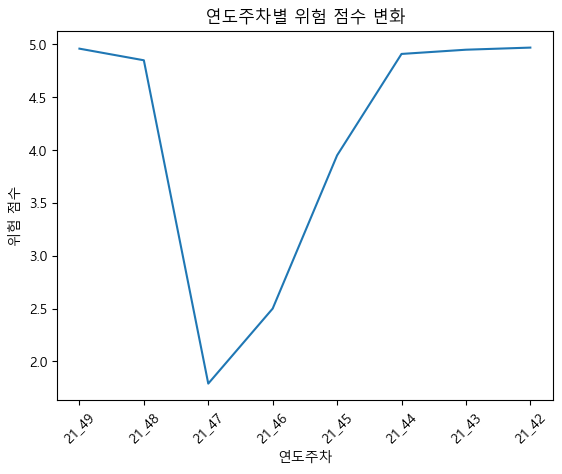

HS Code : 4202211090
      연도주차      단가      신고중량
0    17_04 241.437 86358.604
1    17_05 253.736 85259.408
2    17_06 287.815 77440.904
3    17_07 347.777 64710.518
4    17_08 382.386 58206.624
..     ...     ...       ...
292  22_34 426.882 64018.511
293  22_35 384.009 63360.915
294  22_36 408.313 55806.285
295  22_37 391.068 57839.474
296  22_38 397.270 60499.710

[297 rows x 3 columns]
21_49주차
[369.52356]
[[369.52356]]
======================= 여기부터 GARCH 모델링 =================================
[42555.23]
======================= 여기부터 GARCH 모델링 =================================
21_48주차
[369.52356]
[[369.52356]]
======================= 여기부터 GARCH 모델링 =================================
[42555.23]
======================= 여기부터 GARCH 모델링 =================================
21_47주차
[369.52356]
[[369.52356]]
======================= 여기부터 GARCH 모델링 =================================
[42555.23]
======================= 여기부터 GARCH 모델링 =================================
21_46주차
[369.52356]
[[369.52356]]


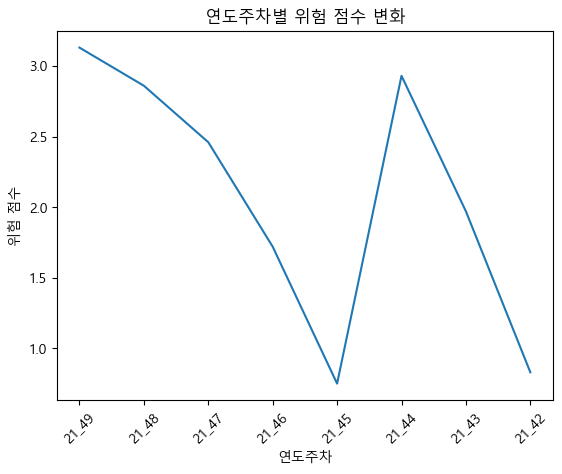

HS Code : 8536509090
      연도주차     단가      신고중량
0    17_04 85.591 74933.006
1    17_05 87.512 69296.354
2    17_06 95.478 64834.179
3    17_07 93.794 64409.350
4    17_08 97.208 63514.715
..     ...    ...       ...
292  22_34 84.772 55762.381
293  22_35 79.825 60339.219
294  22_36 75.518 59814.403
295  22_37 76.015 57586.281
296  22_38 76.158 55630.371

[297 rows x 3 columns]
21_49주차
[69.34395]
[[69.34395]]
======================= 여기부터 GARCH 모델링 =================================
[46231.215]
======================= 여기부터 GARCH 모델링 =================================
21_48주차
[69.34395]
[[69.34395]]
======================= 여기부터 GARCH 모델링 =================================
[46231.215]
======================= 여기부터 GARCH 모델링 =================================
21_47주차
[69.34395]
[[69.34395]]
======================= 여기부터 GARCH 모델링 =================================
[46231.215]
======================= 여기부터 GARCH 모델링 =================================
21_46주차
[69.34395]
[[69.34395]]
=================

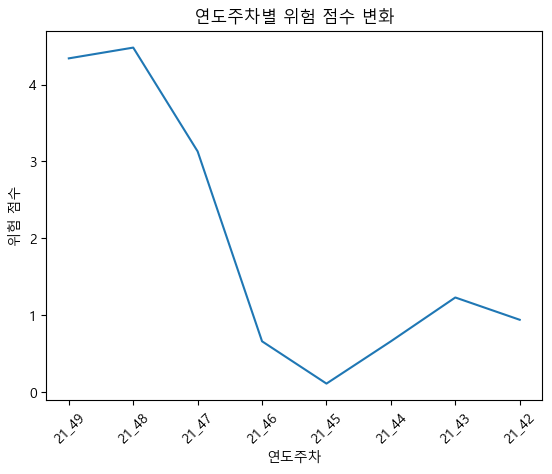

HS Code : 8538909000
      연도주차     단가       신고중량
0    17_04 44.245 273949.515
1    17_05 46.217 278870.289
2    17_06 43.802 267217.483
3    17_07 44.970 288166.458
4    17_08 44.516 298250.785
..     ...    ...        ...
292  22_34 44.666 240827.022
293  22_35 43.916 246156.983
294  22_36 46.418 221859.859
295  22_37 46.694 206086.687
296  22_38 47.247 203948.780

[297 rows x 3 columns]
21_49주차
[41.302624]
[[41.302624]]
======================= 여기부터 GARCH 모델링 =================================
[181936.03]
======================= 여기부터 GARCH 모델링 =================================
21_48주차
[41.302624]
[[41.302624]]
======================= 여기부터 GARCH 모델링 =================================
[181936.03]
======================= 여기부터 GARCH 모델링 =================================
21_47주차
[41.302624]
[[41.302624]]
======================= 여기부터 GARCH 모델링 =================================
[181936.03]
======================= 여기부터 GARCH 모델링 =================================
21_46주차
[41.30262]
[[41.30262]]

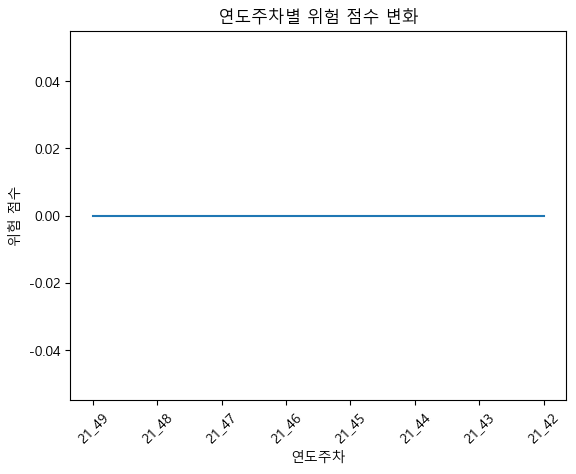

HS Code : 8479909090
      연도주차     단가       신고중량
0    17_04 70.234 150477.045
1    17_05 69.507 140607.283
2    17_06 75.512 131932.099
3    17_07 69.869 124617.381
4    17_08 76.520 134318.584
..     ...    ...        ...
292  22_34 76.835 107975.626
293  22_35 69.784 129008.410
294  22_36 69.289 120004.101
295  22_37 70.436 116425.652
296  22_38 70.507 111990.197

[297 rows x 3 columns]
21_49주차
[33.962017]
[[33.962017]]
======================= 여기부터 GARCH 모델링 =================================
[75683.8]
======================= 여기부터 GARCH 모델링 =================================
21_48주차
[33.962017]
[[33.962017]]
======================= 여기부터 GARCH 모델링 =================================
[75683.8]
======================= 여기부터 GARCH 모델링 =================================
21_47주차
[33.962017]
[[33.962017]]
======================= 여기부터 GARCH 모델링 =================================
[75683.8]
======================= 여기부터 GARCH 모델링 =================================
21_46주차
[33.962017]
[[33.962017]]
===

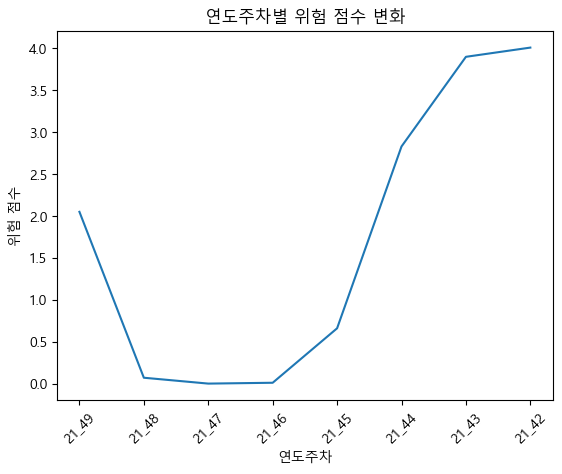

HS Code : 8504409099
      연도주차     단가       신고중량
0    17_04 45.508 147796.603
1    17_05 46.117 144585.070
2    17_06 51.218 137630.769
3    17_07 53.410 149536.397
4    17_08 57.144 144074.529
..     ...    ...        ...
292  22_34 87.083 169955.685
293  22_35 77.439 194442.378
294  22_36 68.709 179084.971
295  22_37 67.253 213412.513
296  22_38 68.693 204341.662

[297 rows x 3 columns]
21_49주차
[46.40274]
[[46.40274]]
======================= 여기부터 GARCH 모델링 =================================
[151891.83]
======================= 여기부터 GARCH 모델링 =================================
21_48주차
[46.40274]
[[46.40274]]
======================= 여기부터 GARCH 모델링 =================================
[151891.83]
======================= 여기부터 GARCH 모델링 =================================
21_47주차
[46.40274]
[[46.40274]]
======================= 여기부터 GARCH 모델링 =================================
[151891.83]
======================= 여기부터 GARCH 모델링 =================================
21_46주차
[46.40274]
[[46.40274]]
=====

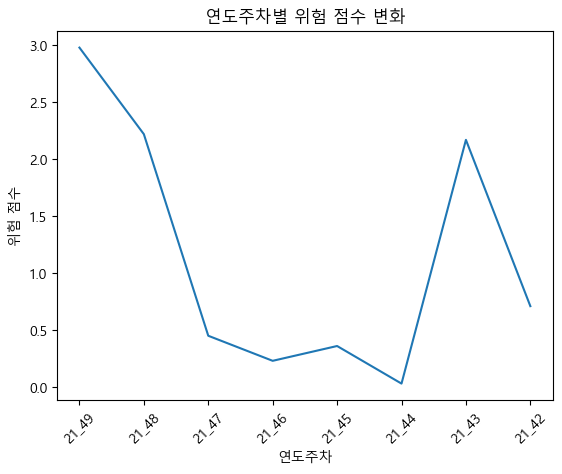

HS Code : 6110909000
      연도주차      단가      신고중량
0    17_04 124.642  7195.191
1    17_05 142.168  7203.119
2    17_06 153.322  6683.793
3    17_07 144.904  7763.641
4    17_08 154.284  7774.726
..     ...     ...       ...
292  22_34 217.578  6996.452
293  22_35 221.461  6778.470
294  22_36 213.702  7014.681
295  22_37 211.003  7409.746
296  22_38 163.716 10115.918

[297 rows x 3 columns]
21_49주차
[120.54199]
[[120.54199]]
======================= 여기부터 GARCH 모델링 =================================
[4246.866]
======================= 여기부터 GARCH 모델링 =================================
21_48주차
[120.54199]
[[120.54199]]
======================= 여기부터 GARCH 모델링 =================================
[4246.866]
======================= 여기부터 GARCH 모델링 =================================
21_47주차
[120.54199]
[[120.54199]]
======================= 여기부터 GARCH 모델링 =================================
[4246.866]
======================= 여기부터 GARCH 모델링 =================================
21_46주차
[120.54199]
[[120.54199]]


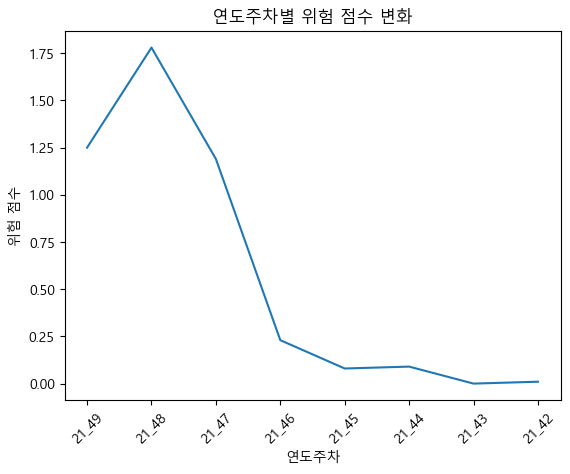

HS Code : 3923100000
      연도주차    단가        신고중량
0    17_04 3.845 2472212.036
1    17_05 3.947 2400024.796
2    17_06 3.963 2370141.074
3    17_07 3.924 2302460.438
4    17_08 3.980 2279496.652
..     ...   ...         ...
292  22_34 3.679 2783491.179
293  22_35 3.784 2712156.118
294  22_36 3.948 2329172.214
295  22_37 3.894 2485633.502
296  22_38 4.065 2371622.391

[297 rows x 3 columns]
21_49주차
[3.5635483]
[[3.5635483]]
======================= 여기부터 GARCH 모델링 =================================
[2.4102002e+06]
======================= 여기부터 GARCH 모델링 =================================
21_48주차
[3.5635483]
[[3.5635483]]
======================= 여기부터 GARCH 모델링 =================================
[2.4102002e+06]
======================= 여기부터 GARCH 모델링 =================================
21_47주차
[3.5635483]
[[3.5635483]]
======================= 여기부터 GARCH 모델링 =================================
[2.4102002e+06]
======================= 여기부터 GARCH 모델링 =================================
21_46주차
[3.5635483]

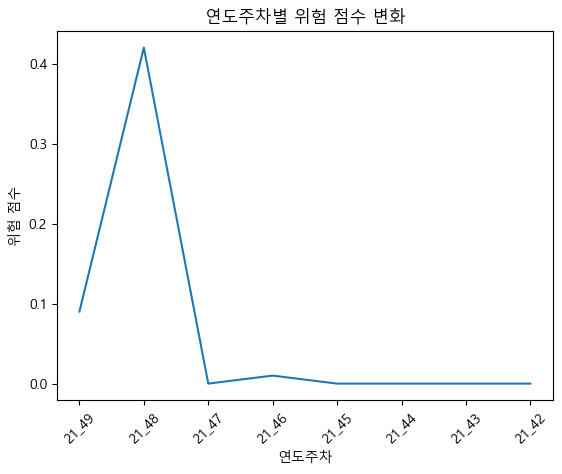

HS Code : 8544422090
      연도주차     단가       신고중량
0    17_04 16.164 444903.567
1    17_05 16.603 414321.924
2    17_06 17.041 384241.238
3    17_07 16.985 366517.775
4    17_08 17.387 359789.977
..     ...    ...        ...
292  22_34 23.253 456410.142
293  22_35 22.436 495383.218
294  22_36 21.952 493127.280
295  22_37 23.081 484107.434
296  22_38 22.899 479771.476

[297 rows x 3 columns]
21_49주차
[17.68285]
[[17.68285]]
======================= 여기부터 GARCH 모델링 =================================
[502699.28]
======================= 여기부터 GARCH 모델링 =================================
21_48주차
[17.68285]
[[17.68285]]
======================= 여기부터 GARCH 모델링 =================================
[502699.28]
======================= 여기부터 GARCH 모델링 =================================
21_47주차
[17.68285]
[[17.68285]]
======================= 여기부터 GARCH 모델링 =================================
[502699.28]
======================= 여기부터 GARCH 모델링 =================================
21_46주차
[17.68285]
[[17.68285]]
=====

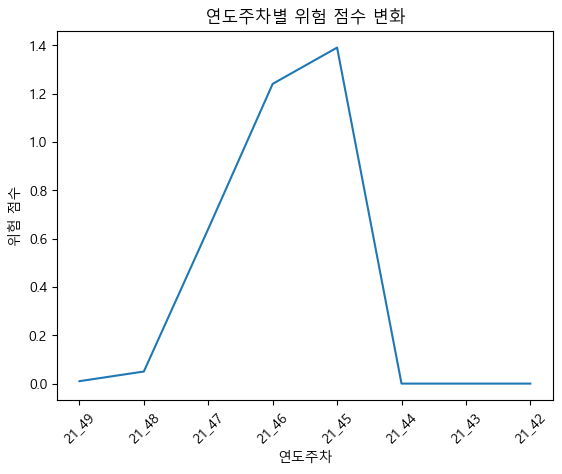

HS Code : 8537109000
      연도주차      단가       신고중량
0    17_04 100.855 126453.495
1    17_05  95.918 129135.848
2    17_06  98.645 114158.314
3    17_07 110.859 115756.420
4    17_08 107.101 117317.871
..     ...     ...        ...
292  22_34  26.557   1093.500
293  22_35  26.557   1093.500
294  22_36  26.557   1093.500
295  22_37  26.557   1093.500
296  22_38  26.557   1093.500

[297 rows x 3 columns]
21_49주차
[100.68767]
[[100.68767]]
======================= 여기부터 GARCH 모델링 =================================
[62095.633]
======================= 여기부터 GARCH 모델링 =================================
21_48주차
[100.68767]
[[100.68767]]
======================= 여기부터 GARCH 모델링 =================================
[62095.633]
======================= 여기부터 GARCH 모델링 =================================
21_47주차
[99.7887]
[[99.7887]]
======================= 여기부터 GARCH 모델링 =================================
[62095.637]
======================= 여기부터 GARCH 모델링 =================================
21_46주차
[97.56936]
[[97

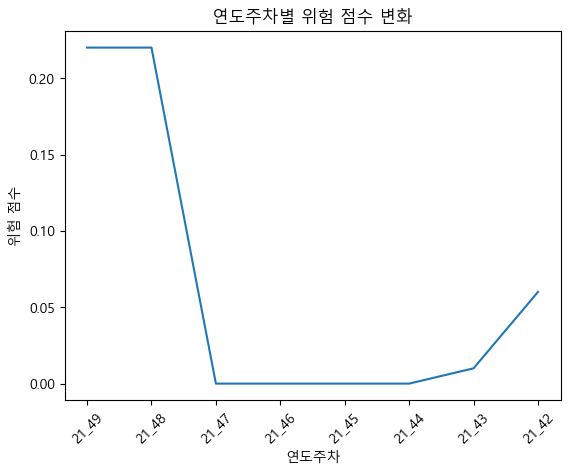

HS Code : 8536699000
      연도주차     단가       신고중량
0    17_04 48.449  84011.851
1    17_05 50.615  84065.514
2    17_06 54.078  74430.699
3    17_07 54.518  71483.045
4    17_08 57.920  69389.533
..     ...    ...        ...
292  22_34 43.083 103756.812
293  22_35 46.169 108270.748
294  22_36 43.516 106938.651
295  22_37 43.547 109731.120
296  22_38 43.044 109433.621

[297 rows x 3 columns]
21_49주차
[32.177235]
[[32.177235]]
======================= 여기부터 GARCH 모델링 =================================
[110936.08]
======================= 여기부터 GARCH 모델링 =================================
21_48주차
[32.177235]
[[32.177235]]
======================= 여기부터 GARCH 모델링 =================================
[110936.08]
======================= 여기부터 GARCH 모델링 =================================
21_47주차
[32.177235]
[[32.177235]]
======================= 여기부터 GARCH 모델링 =================================
[110936.08]
======================= 여기부터 GARCH 모델링 =================================
21_46주차
[32.177235]
[[32.177235

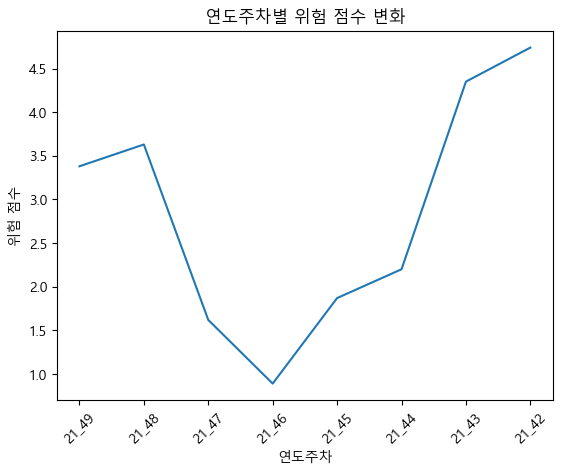

HS Code : 3102109000
      연도주차    단가         신고중량
0    17_04 0.255  5332959.546
1    17_05 0.262  6013912.829
2    17_06 0.266  5785572.955
3    17_07 0.274  6293268.930
4    17_08 0.273  5994605.184
..     ...   ...          ...
292  22_34 0.685 15555657.293
293  22_35 0.675 15785998.656
294  22_36 0.667 13272932.558
295  22_37 0.668 13644743.548
296  22_38 0.678  8370437.638

[297 rows x 3 columns]
21_14주차
[0.25164735]
[[0.25164735]]
======================= 여기부터 GARCH 모델링 =================================
[2.9409328e+06]
======================= 여기부터 GARCH 모델링 =================================
21_13주차
[0.25164735]
[[0.25164735]]
======================= 여기부터 GARCH 모델링 =================================
[2.9409328e+06]
======================= 여기부터 GARCH 모델링 =================================
21_12주차
[0.25164732]
[[0.25164732]]
======================= 여기부터 GARCH 모델링 =================================
[2.9409328e+06]
======================= 여기부터 GARCH 모델링 =================================
2

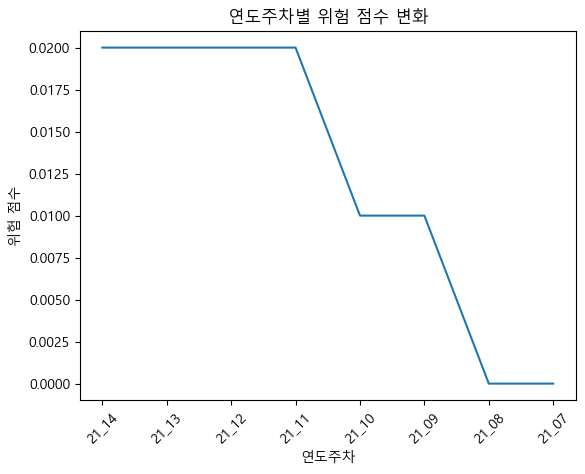

HS Code : 3707901010
      연도주차      단가      신고중량
0    17_04 219.044 17693.709
1    17_05 213.153 21010.400
2    17_06 216.113 19536.734
3    17_07 227.025 18619.221
4    17_08 223.977 18453.471
..     ...     ...       ...
292  22_34 414.585 19852.651
293  22_35 379.294 22915.441
294  22_36 378.936 22876.105
295  22_37 377.473 23998.908
296  22_38 338.724 23399.665

[297 rows x 3 columns]
19_04주차
[210.6163]
[[210.6163]]
======================= 여기부터 GARCH 모델링 =================================
[18193.277]
======================= 여기부터 GARCH 모델링 =================================
19_03주차
[210.6163]
[[210.6163]]
======================= 여기부터 GARCH 모델링 =================================
[15865.118]
======================= 여기부터 GARCH 모델링 =================================
19_02주차
[173.0313]
[[173.0313]]
======================= 여기부터 GARCH 모델링 =================================
[15865.118]
======================= 여기부터 GARCH 모델링 =================================
19_01주차
[173.0313]
[[173.0313]]
=====

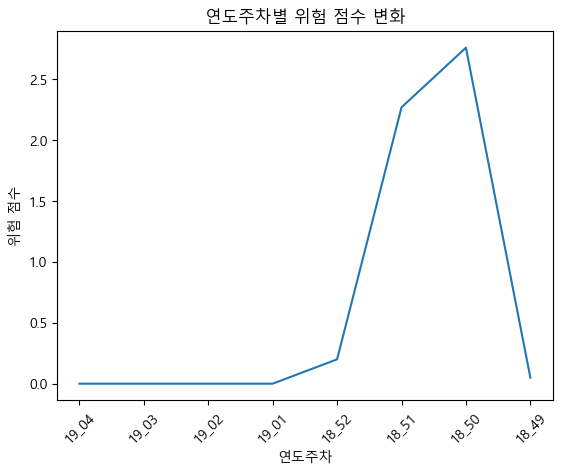

HS Code : 4407191000
      연도주차    단가       신고중량
0    17_04 1.321 239293.247
1    17_05 1.320 250460.747
2    17_06 1.335 267243.948
3    17_07 1.353 205743.000
4    17_08 1.355 166353.875
..     ...   ...        ...
292  22_34 1.459  46860.691
293  22_35 1.597  55567.169
294  22_36 1.587  60067.169
295  22_37 1.328  54362.169
296  22_38 1.313  49607.857

[297 rows x 3 columns]
20_41주차
[1.1209141]
[[1.1209141]]
======================= 여기부터 GARCH 모델링 =================================
[91211.38]
======================= 여기부터 GARCH 모델링 =================================
20_40주차
[1.1209141]
[[1.1209141]]
======================= 여기부터 GARCH 모델링 =================================
[91211.38]
======================= 여기부터 GARCH 모델링 =================================
20_39주차
[1.1209141]
[[1.1209141]]
======================= 여기부터 GARCH 모델링 =================================
[91211.38]
======================= 여기부터 GARCH 모델링 =================================
20_38주차
[1.1209141]
[[1.1209141]]
============

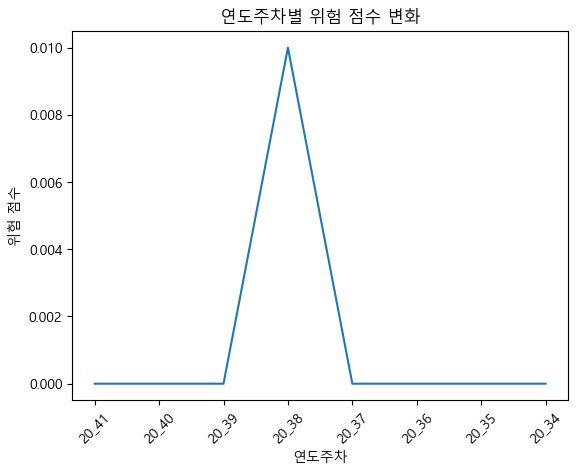

HS Code : 8111000000
      연도주차    단가        신고중량
0    17_04 2.294 1589538.823
1    17_05 2.322 1797062.025
2    17_06 2.349 2135029.125
3    17_07 2.255 2589847.688
4    17_08 2.222 2647460.135
..     ...   ...         ...
292  22_34 2.417 1887338.301
293  22_35 2.470 1322372.493
294  22_36 2.402 1172857.531
295  22_37 2.328 1437803.669
296  22_38 2.315  991759.689

[297 rows x 3 columns]
21_19주차
[1.44577]
[[1.44577]]
======================= 여기부터 GARCH 모델링 =================================
[881444.]
======================= 여기부터 GARCH 모델링 =================================
21_18주차
[1.44577]
[[1.44577]]
======================= 여기부터 GARCH 모델링 =================================
[881444.]
======================= 여기부터 GARCH 모델링 =================================
21_17주차
[1.4457699]
[[1.4457699]]
======================= 여기부터 GARCH 모델링 =================================
[881444.]
======================= 여기부터 GARCH 모델링 =================================
21_16주차
[1.44577]
[[1.44577]]
===============

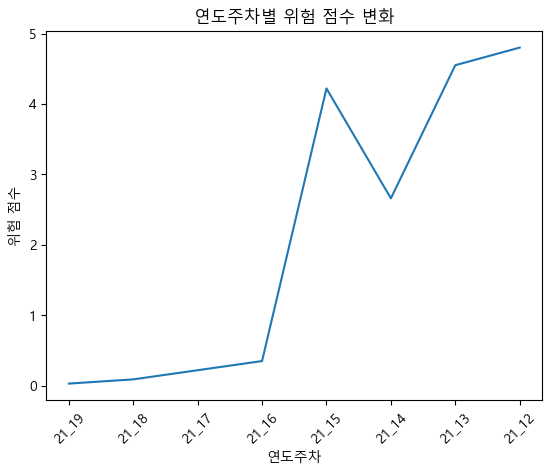

HS Code : 2701129010
      연도주차    단가          신고중량
0    17_04 0.177 163414532.500
1    17_05 0.183 128339537.000
2    17_06 0.187  77542167.000
3    17_07 0.178  87019096.075
4    17_08 0.165 107989167.275
..     ...   ...           ...
292  22_34 0.285 145518255.411
293  22_35 0.274 197342702.911
294  22_36 0.280 214007115.594
295  22_37 0.268 198569715.141
296  22_38 0.273 160074550.041

[297 rows x 3 columns]
21_25주차
[0.09541706]
[[0.09541706]]
======================= 여기부터 GARCH 모델링 =================================
[7.766918e+07]
======================= 여기부터 GARCH 모델링 =================================
21_24주차
[0.09541706]
[[0.09541706]]
======================= 여기부터 GARCH 모델링 =================================
[7.766918e+07]
======================= 여기부터 GARCH 모델링 =================================
21_23주차
[0.09541706]
[[0.09541706]]
======================= 여기부터 GARCH 모델링 =================================
[7.766918e+07]
======================= 여기부터 GARCH 모델링 ==========================

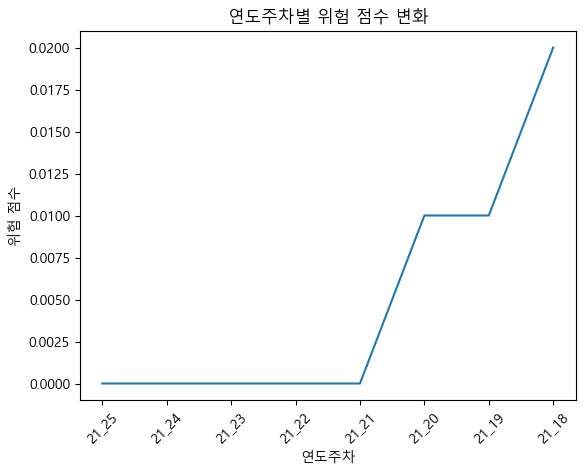

HS Code : 2804701000
      연도주차    단가       신고중량
0    17_04 2.811 160032.550
1    17_05 2.856 164322.550
2    17_06 2.862 142277.500
3    17_07 2.849 143690.000
4    17_08 2.827 128430.000
..     ...   ...        ...
292  22_34 7.502 144652.712
293  22_35 7.193 160465.212
294  22_36 7.270 198465.212
295  22_37 7.206 209505.000
296  22_38 7.230 164662.500

[297 rows x 3 columns]
21_25주차
[2.7989445]
[[2.7989445]]
======================= 여기부터 GARCH 모델링 =================================
[106027.51]
======================= 여기부터 GARCH 모델링 =================================
21_24주차
[2.7989445]
[[2.7989445]]
======================= 여기부터 GARCH 모델링 =================================
[106027.51]
======================= 여기부터 GARCH 모델링 =================================
21_23주차
[2.7989445]
[[2.7989445]]
======================= 여기부터 GARCH 모델링 =================================
[106027.51]
======================= 여기부터 GARCH 모델링 =================================
21_22주차
[2.7989445]
[[2.7989445]]
=========

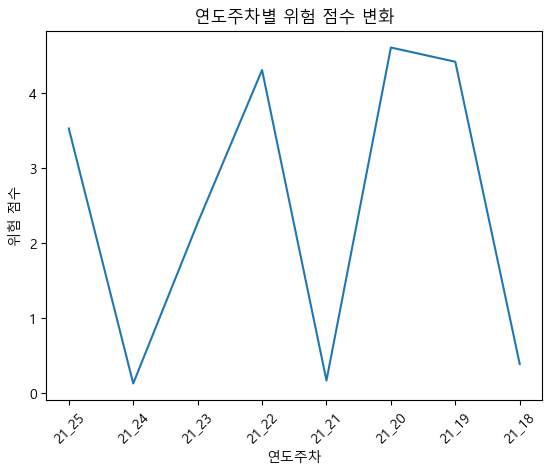

HS Code : 1511901000
      연도주차    단가        신고중량
0    17_04 0.735  936849.355
1    17_05 0.734  930738.055
2    17_06 0.754  893311.305
3    17_07 0.756 1637404.305
4    17_08 0.774 1212247.700
..     ...   ...         ...
292  22_34 1.468  759382.356
293  22_35 1.501  785201.626
294  22_36 1.488  774298.645
295  22_37 1.569  271958.020
296  22_38 1.391  698774.770

[297 rows x 3 columns]
21_29주차
[0.61986154]
[[0.61986154]]
======================= 여기부터 GARCH 모델링 =================================
[106864.5]
======================= 여기부터 GARCH 모델링 =================================
21_28주차
[0.61986154]
[[0.61986154]]
======================= 여기부터 GARCH 모델링 =================================
[106864.5]
======================= 여기부터 GARCH 모델링 =================================
21_27주차
[0.61870503]
[[0.61870503]]
======================= 여기부터 GARCH 모델링 =================================
[149505.]
======================= 여기부터 GARCH 모델링 =================================
21_26주차
[0.61870503]
[[0.6187

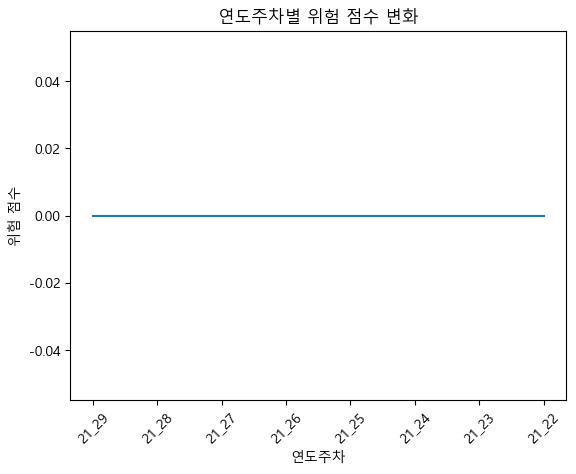

HS Code : 305531000
      연도주차     단가       신고중량
0    17_04 10.143 112739.000
1    17_05 10.020 106671.250
2    17_06  9.953 107973.500
3    17_07  9.665  98612.500
4    17_08  9.570  93437.500
..     ...    ...        ...
292  22_34 10.917 132790.114
293  22_35 10.543 146227.391
294  22_36 10.839 132587.659
295  22_37 10.828 108393.587
296  22_38 10.431  98649.147

[297 rows x 3 columns]
21_34주차
[9.195812]
[[9.195812]]
======================= 여기부터 GARCH 모델링 =================================
[94605.35]
======================= 여기부터 GARCH 모델링 =================================
21_33주차
[9.195812]
[[9.195812]]
======================= 여기부터 GARCH 모델링 =================================
[94605.35]
======================= 여기부터 GARCH 모델링 =================================
21_32주차
[9.195812]
[[9.195812]]
======================= 여기부터 GARCH 모델링 =================================
[94605.35]
======================= 여기부터 GARCH 모델링 =================================
21_31주차
[9.195812]
[[9.195812]]
=========

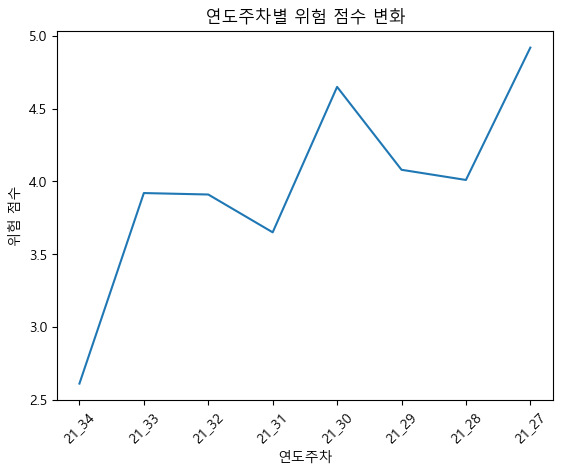

HS Code : 302140000
      연도주차     단가       신고중량
0    17_04 12.297 248997.765
1    17_05 11.776 247770.110
2    17_06 11.204 258943.758
3    17_07 10.781 262438.498
4    17_08 10.400 279016.205
..     ...    ...        ...
292  22_34 13.914 361472.777
293  22_35 13.643 378891.888
294  22_36 13.112 381338.341
295  22_37 12.738 381753.838
296  22_38 12.394 386434.054

[297 rows x 3 columns]
21_35주차
[7.300792]
[[7.300792]]
======================= 여기부터 GARCH 모델링 =================================
[432161.44]
======================= 여기부터 GARCH 모델링 =================================
21_34주차
[7.300792]
[[7.300792]]
======================= 여기부터 GARCH 모델링 =================================
[429810.97]
======================= 여기부터 GARCH 모델링 =================================
21_33주차
[7.300792]
[[7.300792]]
======================= 여기부터 GARCH 모델링 =================================
[429810.97]
======================= 여기부터 GARCH 모델링 =================================
21_32주차
[7.300792]
[[7.300792]]
======

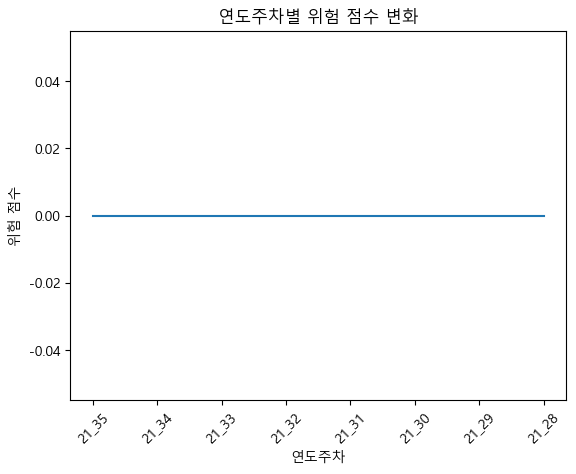

HS Code : 1003901000
      연도주차    단가        신고중량
0    17_04 0.288 1533750.000
1    17_05 0.288 1533750.000
2    17_06 0.288 1533750.000
3    17_07 0.288 1533750.000
4    17_08 0.288 1533750.000
..     ...   ...         ...
292  22_34 0.474  136245.000
293  22_35 0.442  384820.000
294  22_36 0.448  399849.500
295  22_37 0.461  360794.500
296  22_38 0.454  345794.500

[297 rows x 3 columns]
21_34주차
[0.21625479]
[[0.21625479]]
======================= 여기부터 GARCH 모델링 =================================
[56103.5]
======================= 여기부터 GARCH 모델링 =================================
21_33주차
[0.2162548]
[[0.2162548]]
======================= 여기부터 GARCH 모델링 =================================
[10000.25]
======================= 여기부터 GARCH 모델링 =================================
21_32주차
[0.2162548]
[[0.2162548]]
======================= 여기부터 GARCH 모델링 =================================
[10000.25]
======================= 여기부터 GARCH 모델링 =================================
21_31주차
[0.2162548]
[[0.2162548]]

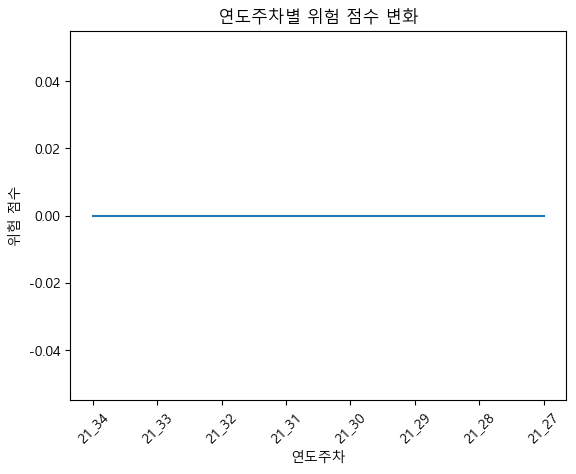

HS Code : 1003902000
      연도주차    단가        신고중량
0    17_04 0.192 3149912.500
1    17_05 0.192 3412412.500
2    17_06 0.192 2054420.000
3    17_07 0.192 1861815.000
4    17_08 0.192  354402.500
..     ...   ...         ...
292  22_34 0.383  183362.562
293  22_35 0.383  183362.562
294  22_36 0.366  116280.000
295  22_37 0.379   75557.500
296  22_38 0.379   75557.500

[297 rows x 3 columns]
21_34주차
[0.20611715]
[[0.20611715]]
======================= 여기부터 GARCH 모델링 =================================
[26125.]
======================= 여기부터 GARCH 모델링 =================================
21_33주차
[0.20611715]
[[0.20611715]]
======================= 여기부터 GARCH 모델링 =================================
[26125.]
======================= 여기부터 GARCH 모델링 =================================
21_32주차
[0.20611715]
[[0.20611715]]
======================= 여기부터 GARCH 모델링 =================================
[26125.]
======================= 여기부터 GARCH 모델링 =================================
21_31주차
[0.20611715]
[[0.20611715]

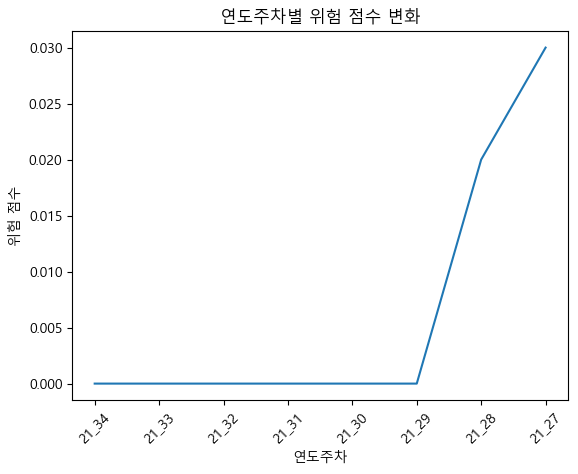

HS Code : 1104230000
      연도주차    단가       신고중량
0    17_04 0.389  38475.125
1    17_05 0.430 166375.125
2    17_06 0.477 415325.600
3    17_07 0.478 462700.475
4    17_08 0.475 537900.475
..     ...   ...        ...
292  22_34 0.451 446502.199
293  22_35 0.448 560500.000
294  22_36 0.447 413250.000
295  22_37 0.465 337250.000
296  22_38 0.473 231750.000

[297 rows x 3 columns]
21_34주차
[0.35900056]
[[0.35900056]]
======================= 여기부터 GARCH 모델링 =================================
[12.049999]
======================= 여기부터 GARCH 모델링 =================================
21_33주차
[0.35900056]
[[0.35900056]]
======================= 여기부터 GARCH 모델링 =================================
[12.049999]
======================= 여기부터 GARCH 모델링 =================================
21_32주차
[0.35900056]
[[0.35900056]]
======================= 여기부터 GARCH 모델링 =================================
[12.049999]
======================= 여기부터 GARCH 모델링 =================================
21_31주차
[0.35900056]
[[0.35900056]]
=

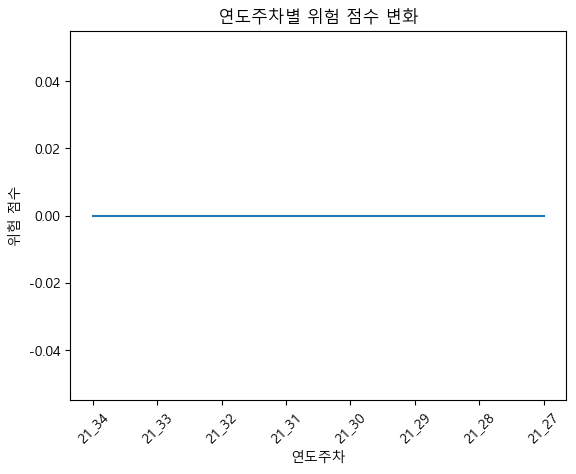

HS Code : 2710121000
      연도주차    단가         신고중량
0    17_04 0.551  2149886.250
1    17_05 0.550  4114309.500
2    17_06 0.549  6381111.750
3    17_07 0.549  4234150.250
4    17_08 0.547  9687853.750
..     ...   ...          ...
292  22_34 0.801 16626932.000
293  22_35 0.955  9728367.250
294  22_36 0.916  8810688.000
295  22_37 0.916  8810688.000
296  22_38 0.713 14231087.750

[297 rows x 3 columns]
21_34주차
[0.38157147]
[[0.38157147]]
======================= 여기부터 GARCH 모델링 =================================
[177156.75]
======================= 여기부터 GARCH 모델링 =================================
21_33주차
[0.38157144]
[[0.38157144]]
======================= 여기부터 GARCH 모델링 =================================
[177156.75]
======================= 여기부터 GARCH 모델링 =================================
21_32주차
[0.38157144]
[[0.38157144]]
======================= 여기부터 GARCH 모델링 =================================
[177156.75]
======================= 여기부터 GARCH 모델링 =================================
21_31주차
[0.38

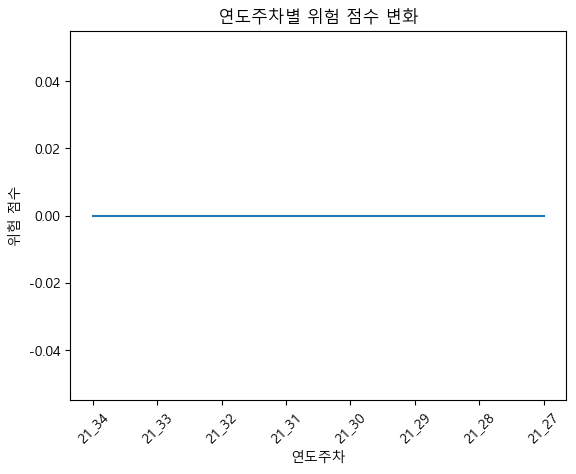

HS Code : 3104200000
      연도주차    단가         신고중량
0    17_04 0.299 11374102.375
1    17_05 0.298 16317880.400
2    17_06 0.291 12415604.100
3    17_07 0.291 10819745.700
4    17_08 0.289 11582318.950
..     ...   ...          ...
292  22_34 0.992 29386228.624
293  22_35 1.007  9666683.242
294  22_36 1.006  9627907.123
295  22_37 1.007  9785683.655
296  22_38 1.010  2767031.598

[297 rows x 3 columns]
21_34주차
[0.25980258]
[[0.25980258]]
======================= 여기부터 GARCH 모델링 =================================
[841401.2]
======================= 여기부터 GARCH 모델링 =================================
21_33주차
[0.25980258]
[[0.25980258]]
======================= 여기부터 GARCH 모델링 =================================
[841401.2]
======================= 여기부터 GARCH 모델링 =================================
21_32주차
[0.25980258]
[[0.25980258]]
======================= 여기부터 GARCH 모델링 =================================
[841401.2]
======================= 여기부터 GARCH 모델링 =================================
21_31주차
[0.25980

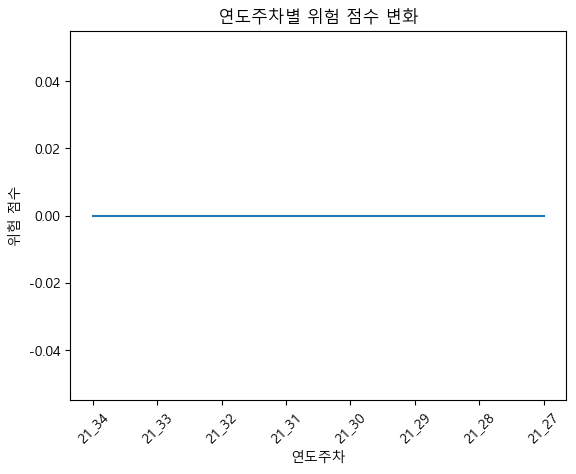

HS Code : 2905172000
      연도주차    단가       신고중량
0    17_04 1.801  49211.300
1    17_05 1.754  65983.925
2    17_06 1.838  79977.625
3    17_07 1.857  61760.131
4    17_08 1.863  63759.256
..     ...   ...        ...
292  22_34 3.054 100640.853
293  22_35 3.011 131752.708
294  22_36 2.871 136344.133
295  22_37 2.882  95667.133
296  22_38 2.817  62904.505

[297 rows x 3 columns]
21_43주차
[1.3850161]
[[1.3850161]]
======================= 여기부터 GARCH 모델링 =================================
[49280.598]
======================= 여기부터 GARCH 모델링 =================================
21_42주차
[1.3850161]
[[1.3850161]]
======================= 여기부터 GARCH 모델링 =================================
[49280.598]
======================= 여기부터 GARCH 모델링 =================================
21_41주차
[1.3850161]
[[1.3850161]]
======================= 여기부터 GARCH 모델링 =================================
[48503.004]
======================= 여기부터 GARCH 모델링 =================================
21_40주차
[1.3850161]
[[1.3850161]]
=========

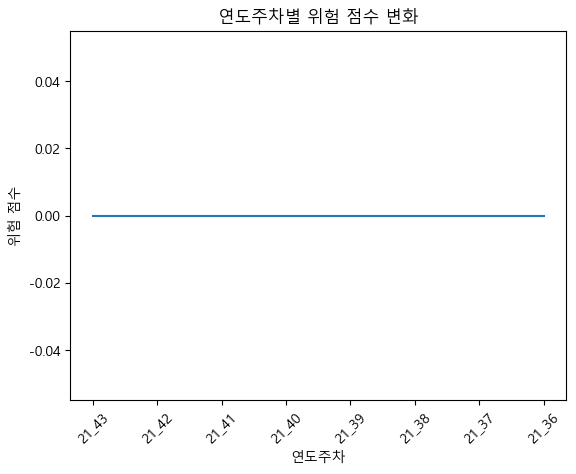

[4.84, 0, 4.43, 0.13, 0, 0.18, 0.11, 0.19, 0, 0.04, 1.31, 4.58, 4.36, 3.93, 4.94, 0.43, 0.28, 1.52, 0.4, 0.65, 1.01, 0.04, 4.19, 1.74, 4.97, 3.13, 4.48, 0, 4.01, 2.98, 1.78, 0.42, 1.39, 0.22, 4.74, 0.02, 2.76, 0.01, 4.8, 0.02, 4.61, 0, 4.92, 0, 0, 0.03, 0, 0, 0, 0]
[49, 0, 42, 48, 0, 43, 47, 48, 0, 43, 49, 44, 43, 46, 47, 48, 48, 42, 42, 42, 49, 48, 43, 45, 49, 42, 43, 0, 49, 42, 43, 43, 46, 42, 49, 77, 198, 106, 79, 73, 71, 0, 64, 0, 0, 64, 0, 0, 0, 0]


In [7]:
리스트 = pd.read_excel('c:\python\list(m).xlsx')
추출용 = 리스트.iloc[:,0].tolist()
리스트 = pd.read_excel('c:\python\list(m1).xlsx')
b = 리스트.iloc[:,0].tolist()

z = []
c = []
e = []
k = []
o = []
z_x = []
z_y = []

for i in range(0, len(추출용)):
  z.append(0) # 품목별 Highest CV를 반영하기 위해 List 생성
  c.append(0) # 품목별 CV값이 임계값 이상인 경우의 횟수를 반영하기 위한 List 생성
  k.append(0) # 임계값을 넘는 횟수
  o.append(0) # 위험경보 여부
  z_x.append(0) # Highest CV의 X값
  z_y.append(0) # Highest CV의 y값

for i in range(0, 8):
  e.append(0) # 품목별 8주간 CV값을 반영하기 위한 List 생성성

j = 0

for i in 추출용:
    print(f'HS Code : {i}')
    original[original['HS10단위부호'] == str(i)].sort_values(by = '수리일자', ascending = False)
    data = pd.DataFrame(columns = use_col)
    data = pd.concat([data, original[original['HS10단위부호'] == str(i)]])
    data = data.reset_index(drop=True)

    data = data.sort_values(by='수리일자', ascending=True).reset_index(drop=True)
    
    #
    ## 최근 52주간 수입단가(직전4주평균) 추이 파악
    #
    df_price = data[['연도주차', '과세가격미화금액', '신고중량']]
    df_price_week = df_price.groupby('연도주차')[['과세가격미화금액', '신고중량']].agg(['sum']).reset_index()
    df_price_week.columns = ['연도주차', '과세가격미화금액', '신고중량']


    # 수입이 없는 주차의 값을 0으로 생성
    df_price_week_hole = pd.DataFrame(columns = df_price_week.columns)
    for wk in set(date_index) - set(df_price_week['연도주차'].unique()):
        df_price_week_hole = pd.concat([df_price_week_hole, pd.DataFrame([{'연도주차': wk, '과세가격미화금액': 0, '신고중량': 0}])], ignore_index=True)
    df_price_week_total = pd.concat([df_price_week, df_price_week_hole]).sort_values('연도주차')

    # 해당 주차의 데이터를 직전 4주간 평균으로 대체
    price_w4 = []
    kg_w4 = []
    for x in range(0, len(df_price_week_total) - 3):
        price_w4.append(df_price_week_total[['과세가격미화금액']].iloc[x : x + 4].mean().iloc[0])
        kg_w4.append(df_price_week_total[['신고중량']].iloc[x : x + 4].mean().iloc[0])
    df_price_4w = df_price_week_total[3:]
    df_price_4w['과세가격미화금액'] = price_w4
    df_price_4w['신고중량'] = kg_w4
    df_price_4w = df_price_4w.reset_index(drop = True)
    df_price_4w['과세가격미화금액'] = df_price_4w['과세가격미화금액'].replace(0, np.nan).ffill()
    df_price_4w['신고중량'] = df_price_4w['신고중량'].replace(0, np.nan).ffill()
    df_price_4w['단가'] = df_price_4w['과세가격미화금액'] / df_price_4w['신고중량']
    df_price_4w = df_price_4w[['연도주차', '단가', '신고중량']]
    df_price_4w = df_price_4w.bfill()
    print(df_price_4w)

    residuals_list1 = []
    residuals_list2 = []

    for m in range(8, len(df_price_4w)):  # 최소 8개 이상 필요 (4주 평균+4주 윈도우)
        # 데이터 준비
        train_y = df_price_4w['단가'].iloc[m-8:m].values.reshape(-1, 1)
        test_y = df_price_4w['단가'].iloc[m:m+1].values.reshape(-1, 1)

        # 정규화
        ms = MinMaxScaler()
        y_train = ms.fit_transform(train_y)
        y_test = ms.transform(test_y)

        # 텐서 변환
        X_train = Variable(torch.Tensor(y_train)).reshape(-1, 8, 1)
        y_train_t = Variable(torch.Tensor(y_train))

        X_test = Variable(torch.Tensor(ms.transform(train_y[-8:]))).reshape(1, 8, 1)
        y_test_t = Variable(torch.Tensor(y_test))

        # 모델 정의
        model = LSTM(num_classes=1, input_size=1, hidden_size=16, num_layers=1, seq_length=8)
        criterion = torch.nn.MSELoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

        # 학습
        for epoch in range(30):
            output = model(X_train)
            loss = criterion(output, y_train_t)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        # 예측 및 역변환
        pred = model(X_test)
        pred_inv = ms.inverse_transform(pred.data.numpy())
        true_inv = ms.inverse_transform(y_test)

        # 잔차 저장
        residual = true_inv[0][0] - pred_inv[0][0]
        residuals_list1.append(residual)
    
    for n in range(8, len(df_price_4w)):  # 최소 8개 이상 필요 (4주 평균+4주 윈도우)
        # 데이터 준비
        train_y = df_price_4w['신고중량'].iloc[n-8:n].values.reshape(-1, 1)
        test_y = df_price_4w['신고중량'].iloc[n:n+1].values.reshape(-1, 1)

        # 정규화
        ms = MinMaxScaler()
        y_train = ms.fit_transform(train_y)
        y_test = ms.transform(test_y)

        # 텐서 변환
        X_train = Variable(torch.Tensor(y_train)).reshape(-1, 8, 1)
        y_train_t = Variable(torch.Tensor(y_train))

        X_test = Variable(torch.Tensor(ms.transform(train_y[-8:]))).reshape(1, 8, 1)
        y_test_t = Variable(torch.Tensor(y_test))

        # 모델 정의
        model = LSTM(num_classes=1, input_size=1, hidden_size=16, num_layers=1, seq_length=8)
        criterion = torch.nn.MSELoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

        # 학습
        for epoch in range(30):
            output = model(X_train)
            loss = criterion(output, y_train_t)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        # 예측 및 역변환
        pred = model(X_test)
        pred_inv = ms.inverse_transform(pred.data.numpy())
        true_inv = ms.inverse_transform(y_test)

        # 잔차 저장
        residual = true_inv[0][0] - pred_inv[0][0]
        residuals_list2.append(residual)

    for l in range(b[j]-8,b[j]):

        print(df_price_4w['연도주차'].iloc[-1-l] + '주차')
        #=================== 단가 percertile 구하기 ====================
        train_y = df_price_4w['단가'].iloc[p_eriod-l:-l].reset_index(drop=True)
        test_y = df_price_4w['단가'].iloc[p_eriod-l:-l+1].reset_index(drop=True)

        # 스케일링
        ms = MinMaxScaler()
        y_train = ms.fit_transform(train_y.values.reshape(-1, 1))
        y_test = ms.transform(test_y.values.reshape(-1, 1))

        # 텐서 변환 (단일 입력 특성)
        X_train_tensors_f = Variable(torch.Tensor(y_train).reshape(1, -1, 1))  # (1, seq_len=8, 1)
        X_test_tensors_f  = Variable(torch.Tensor(y_train[-8:].reshape(1, -1, 1)))  # 마지막 8개를 사용해 1-step 예측
        y_train_tensors = Variable(torch.Tensor(y_train))
        y_test_tensors = Variable(torch.Tensor(y_test))
        set_seed(3)

        # ========= 하이퍼 파라미터 구간(시작) ==========
        num_epochs = 100
        learning_rate = 0.0001

   
        # ========= 하이퍼 파라미터 구간(종료) ==========
        input_size = 1
        model = LSTM(num_classes=1, input_size=input_size, hidden_size=16, num_layers=1, seq_length=1)
        #model = biLSTM(num_classes, input_size, hidden_size, num_layers, X_train_tensors_f.shape[1])

        criterion = torch.nn.MSELoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

        for epoch in range(num_epochs):
            outputs = model.forward(X_train_tensors_f)
            optimizer.zero_grad()
            loss = criterion(outputs, y_train_tensors)
            loss.backward()

            optimizer.step()
            #if epoch % 100 == 0:
                #print("Epoch: %d, loss: %1.5f" % (epoch, loss.item()))

        test_predict = model(X_test_tensors_f)
        predicted = test_predict.data.numpy()
        #label_y = df_y_ms.data.numpy()

        predicted = ms.inverse_transform(predicted)
        print(predicted[0])

        # 1. biLSTM 예측
        test_predict1 = model(X_test_tensors_f)
        predicted1 = test_predict1.data.numpy()
        predicted2 = ms.inverse_transform(predicted1)
        print(predicted2)
        # 2. 실제값 (복원)
        true_y = ms.inverse_transform(y_test_tensors.data.numpy())

        # 3. 잔차 계산
        #residuals_1d = residuals.flatten()
        print('======================= 여기부터 GARCH 모델링 =================================')
        # 4. GARCH 모델에 적용
        garch = arch.arch_model(residuals_list1, vol="GARCH", p=1, q=1)
        garch_fit = garch.fit(disp="off", options={"maxiter": 1000})
        garch_forecast = garch_fit.forecast(horizon=1)
        garch_std = np.sqrt(garch_forecast.variance.iloc[-1, 0])
        stand_quant = (test_y.iloc[0] - predicted[0])/ garch_std

        y=np.exp((scipy.stats.norm.cdf(stand_quant)*100 - 95)*np.log(5)/5)

      #=================== 신고중량 ======================

        train_y = df_price_4w['신고중량'].iloc[p_eriod-l:-l].reset_index(drop=True)
        test_y = df_price_4w['신고중량'].iloc[p_eriod-l:-l+1].reset_index(drop=True)

        # 스케일링
        ms = MinMaxScaler()
        y_train = ms.fit_transform(train_y.values.reshape(-1, 1))
        y_test = ms.transform(test_y.values.reshape(-1, 1))

        # 텐서 변환 (단일 입력 특성)
        X_train_tensors_f = Variable(torch.Tensor(y_train).reshape(1, -1, 1))  # (1, seq_len=8, 1)
        X_test_tensors_f  = Variable(torch.Tensor(y_train[-8:].reshape(1, -1, 1)))  # 마지막 8개를 사용해 1-step 예측
        y_train_tensors = Variable(torch.Tensor(y_train))
        y_test_tensors = Variable(torch.Tensor(y_test))
        set_seed(3)

        # ========= 하이퍼 파라미터 구간(시작) ==========
        num_epochs = 100
        learning_rate = 0.0001

   
        # ========= 하이퍼 파라미터 구간(종료) ==========
        input_size = 1
        model = LSTM(num_classes=1, input_size=input_size, hidden_size=16, num_layers=1, seq_length=1)
        #model = biLSTM(num_classes, input_size, hidden_size, num_layers, X_train_tensors_f.shape[1])

        criterion = torch.nn.MSELoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

        for epoch in range(num_epochs):
            outputs = model.forward(X_train_tensors_f)
            optimizer.zero_grad()
            loss = criterion(outputs, y_train_tensors)
            loss.backward()

            optimizer.step()
            #if epoch % 100 == 0:
                #print("Epoch: %d, loss: %1.5f" % (epoch, loss.item()))

        test_predict = model(X_test_tensors_f)
        predicted = test_predict.data.numpy()
        #label_y = df_y_ms.data.numpy()

        predicted = ms.inverse_transform(predicted)
        print(predicted[0])


        print('======================= 여기부터 GARCH 모델링 =================================')
        # 4. GARCH 모델에 적용
        garch = arch.arch_model(residuals_list2, vol="GARCH", p=1, q=1)
        garch_fit = garch.fit(disp="off", options={"maxiter": 1000})
        garch_forecast = garch_fit.forecast(horizon=1)
        garch_std = np.sqrt(garch_forecast.variance.iloc[-1, 0])
        stand_quant = (test_y.iloc[0] - predicted[0])/ garch_std

        if(scipy.stats.norm.cdf(stand_quant)>0.5):
            x=np.exp((scipy.stats.norm.cdf(stand_quant)*100 - 95)*np.log(5)/5)
        else:
            x=np.exp(((1-scipy.stats.norm.cdf(stand_quant))*100 - 95)*np.log(5)/5)

        x = x.item() if isinstance(x, np.ndarray) else x
        y = y.item() if isinstance(y, np.ndarray) else y


        e[(l-b[j]+8)] = round(2/(1/y+1/x), 2)
        if(round(2/(1/y+1/x), 2)>1.85):
            k[j] += 1
        if(z[j] < round(2/(1/y+1/x), 2)):
            z[j] = round(2/(1/y+1/x), 2)
            c[j] = l

        if(z_x[j] < x):
            z_x[j] = x

        if(z_y[j] < y):
            z_y[j] = y

    if(z[j]>1.85):
        o[j] = 1

    import matplotlib.font_manager as fm

    plt.rc('font', family='Malgun Gothic')  # Windows (맑은 고딕)
    plt.rc('axes', unicode_minus=False)  # 마이너스(-) 기호 깨짐 방지

    x_labels = [df_price_4w['연도주차'].iloc[-1-l] for l in range(b[j]-8,b[j])]  # x축 라벨 생성
    plt.plot(x_labels, e)  # x축을 연도주차 값으로 설정
    plt.xticks(rotation=45)  # x축 라벨 회전 (가독성 개선)
    plt.xlabel("연도주차")  # x축 제목 추가
    plt.ylabel("위험 점수")  # y축 제목 추가
    plt.title("연도주차별 위험 점수 변화")  # 그래프 제목 추가
    plt.show()

    j += 1
print(z)
print(c)

# 구글드라이브에 있는 엑셀 파일을 불러와서 점수결과 저장하기
collect = pd.read_excel('c:\python\Compare_Models50.xlsx', sheet_name="점수")
collect = pd.DataFrame(collect)
collect.loc[:49, 'Model20(1)'] = o
collect.loc[50, 'Model20(1)'] = np.sum(o)
collect.loc[:49, 'Model20(2)'] = z
collect.loc[50, 'Model20(2)'] = np.mean(z)
collect.to_excel('c:\python\Compare_Models50.xlsx', sheet_name="점수", index=False)

collect1 = pd.read_excel('c:\python\Collectroc(t).xlsx', sheet_name="점수")
collect1 = pd.DataFrame(collect1)
collect1.loc[15:65, 'y_scores[21]'] = z
collect1.to_excel('c:\python\Collectroc(t).xlsx', sheet_name="점수", index=False)

collect2 = pd.read_excel('c:\python\Collectroc(x).xlsx', sheet_name="점수")
collect2 = pd.DataFrame(collect2)
collect2.loc[15:65, 'y_scores[21]'] = z_x
collect2.to_excel('c:\python\Collectroc(x).xlsx', sheet_name="점수", index=False)

collect3 = pd.read_excel('c:\python\Collectroc(y).xlsx', sheet_name="점수")
collect3 = pd.DataFrame(collect3)
collect3.loc[15:65, 'y_scores[21]'] = z_y
collect3.to_excel('c:\python\Collectroc(y).xlsx', sheet_name="점수", index=False)